In [1]:
import pandas as pd
import numpy as np
import os

print("✅ Imports OK")
print(f"pandas version : {pd.__version__}")
print(f"numpy version  : {np.__version__}")

✅ Imports OK
pandas version : 2.3.1
numpy version  : 2.0.1


In [2]:
!pip install openpyxl

In [3]:
# Change ce chemin selon ton Mac
BASE_PATH = "/Users/zakariaelbaz/Desktop/model bayes 2/leonardo et al"

eis_file  = f"{BASE_PATH}/ExperimentalDATA/EISexpCell01.xlsx"
circ_file = f"{BASE_PATH}/OutputDATA/Circuit_parameter_Cell01.xlsx"

# Test chargement
df_eis  = pd.read_excel(eis_file)
df_circ = pd.read_excel(circ_file)

print(f"✅ EIS loaded    : {df_eis.shape}")
print(f"✅ Circuit loaded: {df_circ.shape}")
print(f"\nEIS columns    : {list(df_eis.columns)}")
print(f"Circuit columns: {list(df_circ.columns)}")

✅ EIS loaded    : (3060, 10)
✅ Circuit loaded: (60, 22)

EIS columns    : ['Aging cycle', 'SOH(%)', 'SOC(%)', 'R_int(%)', 'Frequency(Hz)', 'Zmod(Ohm)', 'Zphz(deg)', 'Zreal(Ohm)', 'Zimg(Ohm)', 'OCV(V)']
Circuit columns: ['SOC', 'aging_cycle', 'L', 'R', 'R_ct1', 'Q1', 'alpha1', 'R_ct2', 'Q2', 'alpha2', 'Zw', 'residual', 'chi2', 'R² Real', 'R² Imag', 'RMSE_Real', 'RMSE_imag', 'R2', 'RMSE', 'LAM\n%', 'LLI', 'CL']


In [4]:
# Rename EIS columns
df_eis.rename(columns={
    'Aging cycle':  'cycle',
    'SOC(%)':       'SoC',
    'SOH(%)':       'SoH',
    'Frequency(Hz)':'freq',
    'Zreal(Ohm)':   'Re_Z',
    'Zimg(Ohm)':    'Im_Z'
}, inplace=True)

# Rename Circuit columns
df_circ.rename(columns={
    'SOC':          'SoC',
    'aging_cycle':  'cycle',
    'R':            'R_ohm',
    'Zw':           'z_w',
    'LAM\n%':       'LAM'
}, inplace=True)

# Sign convention fix
df_eis['neg_Im_Z'] = -df_eis['Im_Z']

print("✅ Rename OK")
print(f"\nEIS columns     : {list(df_eis.columns)}")
print(f"Circuit columns : {list(df_circ.columns)}")
print(f"\nPremières lignes EIS :")
print(df_eis[['cycle','SoC','SoH','freq','Re_Z','Im_Z','neg_Im_Z']].head(8))
print(f"\nPremières lignes Circuit :")
print(df_circ[['cycle','SoC','R_ohm','R_ct1','z_w','LAM','LLI','CL']].head(8))

✅ Rename OK

EIS columns     : ['cycle', 'SoH', 'SoC', 'R_int(%)', 'freq', 'Zmod(Ohm)', 'Zphz(deg)', 'Re_Z', 'Im_Z', 'OCV(V)', 'neg_Im_Z']
Circuit columns : ['SoC', 'cycle', 'L', 'R_ohm', 'R_ct1', 'Q1', 'alpha1', 'R_ct2', 'Q2', 'alpha2', 'z_w', 'residual', 'chi2', 'R² Real', 'R² Imag', 'RMSE_Real', 'RMSE_imag', 'R2', 'RMSE', 'LAM', 'LLI', 'CL']

Premières lignes EIS :
   cycle  SoC    SoH         freq      Re_Z      Im_Z  neg_Im_Z
0      0  100  100.0  9946.650391  0.012102  0.007487 -0.007487
1      0  100  100.0  7888.720215  0.011957  0.005870 -0.005870
2      0  100  100.0  6288.109863  0.011846  0.004540 -0.004540
3      0  100  100.0  5039.062988  0.011810  0.003458 -0.003458
4      0  100  100.0  4001.523926  0.011824  0.002522 -0.002522
5      0  100  100.0  3164.062988  0.011872  0.001717 -0.001717
6      0  100  100.0  2507.267090  0.011969  0.001053 -0.001053
7      0  100  100.0  1979.166992  0.012105  0.000488 -0.000488

Premières lignes Circuit :
   cycle  SoC     R_ohm  

In [5]:
# Spectre complet pour cycle=0, SoC=100
spec = df_eis[
    (df_eis['cycle'] == 0) & 
    (df_eis['SoC'] == 100)
].sort_values('freq', ascending=False).reset_index(drop=True)

print("Spectre complet — cycle=0, SoC=100")
print("="*65)
print(f"{'Freq(Hz)':>12} | {'Re_Z(Ω)':>10} | {'Im_Z(Ω)':>10} | {'-Im_Z':>10}")
print("-"*65)
for _, row in spec.iterrows():
    flag = "← inductif ⚠️" if row['Im_Z'] > 0 else ""
    print(f"{row['freq']:>12.3f} | "
          f"{row['Re_Z']:>10.6f} | "
          f"{row['Im_Z']:>10.6f} | "
          f"{row['neg_Im_Z']:>10.6f}  {flag}")

# Compter les valeurs positives et négatives
n_pos = (df_eis['Im_Z'] > 0).sum()
n_neg = (df_eis['Im_Z'] < 0).sum()
print(f"\nIm_Z > 0 (inductif)  : {n_pos} points")
print(f"Im_Z < 0 (capacitif) : {n_neg} points")

# Trouver la fréquence de transition
spec_transition = spec[spec['Im_Z'] > 0]
if len(spec_transition) > 0:
    f_transition = spec_transition['freq'].min()
    print(f"\nFréquence de transition : {f_transition:.3f} Hz")
    print(f"Au-dessus : inductif (Im_Z > 0)")
    print(f"En-dessous : capacitif (Im_Z < 0)")

Spectre complet — cycle=0, SoC=100
    Freq(Hz) |    Re_Z(Ω) |    Im_Z(Ω) |      -Im_Z
-----------------------------------------------------------------
    9946.650 |   0.012102 |   0.007487 |  -0.007487  ← inductif ⚠️
    7888.720 |   0.011957 |   0.005870 |  -0.005870  ← inductif ⚠️
    6288.110 |   0.011846 |   0.004540 |  -0.004540  ← inductif ⚠️
    5039.063 |   0.011810 |   0.003458 |  -0.003458  ← inductif ⚠️
    4001.524 |   0.011824 |   0.002522 |  -0.002522  ← inductif ⚠️
    3164.063 |   0.011872 |   0.001717 |  -0.001717  ← inductif ⚠️
    2507.267 |   0.011969 |   0.001053 |  -0.001053  ← inductif ⚠️
    1979.167 |   0.012105 |   0.000488 |  -0.000488  ← inductif ⚠️
    1598.011 |   0.012260 |   0.000059 |  -0.000059  ← inductif ⚠️
    1257.622 |   0.012466 |  -0.000343 |   0.000343  
    1004.464 |   0.012690 |  -0.000656 |   0.000656  
     800.305 |   0.012937 |  -0.000912 |   0.000912  
     631.010 |   0.013219 |  -0.001118 |   0.001118  
     498.670 |   0.013507 | 

In [6]:
# Test de merge pour cycle=0, SoC=100
cyc = 0
soc = 100

# Extraire le spectre EIS
eis_subset = df_eis[
    (df_eis['cycle'] == cyc) & 
    (df_eis['SoC'] == soc)
].sort_values('freq', ascending=False).reset_index(drop=True)

# Extraire les paramètres ECM
circ_row = df_circ[
    (df_circ['cycle'] == cyc) & 
    (df_circ['SoC'] == soc)
].iloc[0]

# Construire X_seq (51, 2)
seq = eis_subset[['Re_Z', 'neg_Im_Z']].values.astype(np.float32)

# Construire X_tab (9,)
tab = circ_row[[
    'L', 'R_ohm', 'R_ct1', 'Q1', 'alpha1',
    'R_ct2', 'Q2', 'alpha2', 'z_w'
]].values.astype(np.float32)

# Extraire les cibles
soh = float(eis_subset['SoH'].iloc[0])
soc_val = float(circ_row['SoC'])
lam = float(circ_row['LAM'])
lli = float(circ_row['LLI'])
cl  = float(circ_row['CL'])

print("="*50)
print(f"Test échantillon : cycle={cyc}, SoC={soc}")
print("="*50)
print(f"\nX_seq shape : {seq.shape}")
print(f"X_tab shape : {tab.shape}")
print(f"\nX_seq (5 premières fréquences) :")
print(f"{'Re_Z':>12} | {'neg_Im_Z':>12}")
for i in range(5):
    print(f"{seq[i,0]:>12.6f} | {seq[i,1]:>12.6f}")
print(f"\nX_tab (paramètres ECM) :")
names = ['L','R_ohm','R_ct1','Q1','alpha1',
         'R_ct2','Q2','alpha2','z_w']
for name, val in zip(names, tab):
    print(f"  {name:8s} : {val:.6e}")
print(f"\nCibles :")
print(f"  SoC : {soc_val:.1f}%")
print(f"  SoH : {soh:.2f}%")
print(f"  LAM : {lam:.4f}%")
print(f"  LLI : {lli:.4f}")
print(f"  CL  : {cl:.4f}")

# Vérifications
assert seq.shape == (51, 2), f"❌ seq shape: {seq.shape}"
assert tab.shape == (9,),    f"❌ tab shape: {tab.shape}"
assert not np.any(np.isnan(seq)), "❌ NaN in seq"
assert not np.any(np.isnan(tab)), "❌ NaN in tab"
print(f"\n✅ Toutes les vérifications passées")

Test échantillon : cycle=0, SoC=100

X_seq shape : (51, 2)
X_tab shape : (9,)

X_seq (5 premières fréquences) :
        Re_Z |     neg_Im_Z
    0.012102 |    -0.007487
    0.011957 |    -0.005870
    0.011846 |    -0.004540
    0.011810 |    -0.003458
    0.011824 |    -0.002522

X_tab (paramètres ECM) :
  L        : 1.223856e-07
  R_ohm    : 1.177248e-02
  R_ct1    : 2.143446e-03
  Q1       : 1.068210e-01
  alpha1   : 9.968091e-01
  R_ct2    : 2.582415e-03
  Q2       : 1.303177e+00
  alpha2   : 8.623797e-01
  z_w      : 3.477701e-03

Cibles :
  SoC : 100.0%
  SoH : 100.00%
  LAM : 0.0000%
  LLI : 0.0000
  CL  : 0.0000

✅ Toutes les vérifications passées


In [7]:
# Diagnostiquer chaque cellule problématique

BASE_PATH = "/Users/zakariaelbaz/Desktop/model bayes 2/leonardo et al"

for cell_id in [3, 5, 6, 7, 8]:
    circ_file = f"{BASE_PATH}/OutputDATA/Circuit_parameter_Cell{cell_id:02d}.xlsx"
    eis_file  = f"{BASE_PATH}/ExperimentalDATA/EISexpCell{cell_id:02d}.xlsx"
    
    df_c = pd.read_excel(circ_file)
    df_e = pd.read_excel(eis_file)
    
    df_c.rename(columns={
        'SOC': 'SoC', 'aging_cycle': 'cycle',
        'LAM\n%': 'LAM'
    }, inplace=True)
    df_e.rename(columns={
        'Aging cycle': 'cycle', 'SOC(%)': 'SoC',
        'Frequency(Hz)': 'freq'
    }, inplace=True)
    
    print(f"\n{'='*55}")
    print(f"CELL {cell_id:02d}")
    print(f"{'='*55}")
    
    # Cycles disponibles dans Circuit
    cycles_circ = sorted(df_c['cycle'].unique())
    soc_circ    = sorted(df_c['SoC'].unique())
    print(f"Circuit — cycles    : {cycles_circ}")
    print(f"Circuit — SoC levels: {soc_circ}")
    print(f"Circuit — nb lignes : {len(df_c)}")
    
    # Cycles disponibles dans EIS
    cycles_eis = sorted(df_e['cycle'].unique())
    soc_eis    = sorted(df_e['SoC'].unique())
    print(f"EIS     — cycles    : {cycles_eis}")
    print(f"EIS     — SoC levels: {soc_eis}")
    print(f"EIS     — nb lignes : {len(df_e)}")
    
    # Chercher les doublons dans Circuit
    dupes = df_c[df_c.duplicated(
        subset=['cycle', 'SoC'], keep=False
    )]
    if len(dupes) > 0:
        print(f"\n🚨 DOUBLONS dans Circuit ({len(dupes)} lignes):")
        print(dupes[['cycle', 'SoC']].to_string())
    else:
        print(f"\n✅ Pas de doublons dans Circuit")
    
    # Combinaisons uniques
    combos_circ = set(zip(df_c['cycle'], df_c['SoC']))
    combos_eis  = set(
        zip(df_e['cycle'], df_e['SoC'])
    )
    
    # Dans Circuit mais pas dans EIS
    only_circ = combos_circ - combos_eis
    if only_circ:
        print(f"\n⚠️  Dans Circuit mais PAS dans EIS:")
        for c in sorted(only_circ):
            print(f"   cycle={c[0]}, SoC={c[1]}")
    
    # Dans EIS mais pas dans Circuit
    only_eis = combos_eis - combos_circ
    if only_eis:
        print(f"\n⚠️  Dans EIS mais PAS dans Circuit:")
        for c in sorted(only_eis):
            print(f"   cycle={c[0]}, SoC={c[1]}")


CELL 03
Circuit — cycles    : [np.int64(0), np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(225), np.int64(250), np.int64(275)]
Circuit — SoC levels: [np.int64(0), np.int64(50), np.int64(75), np.int64(100)]
Circuit — nb lignes : 48
EIS     — cycles    : [np.int64(0), np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(225), np.int64(250), np.int64(275)]
EIS     — SoC levels: [np.int64(0), np.int64(25), np.int64(50), np.int64(75), np.int64(100)]
EIS     — nb lignes : 3060

✅ Pas de doublons dans Circuit

⚠️  Dans EIS mais PAS dans Circuit:
   cycle=0, SoC=25
   cycle=25, SoC=25
   cycle=50, SoC=25
   cycle=75, SoC=25
   cycle=100, SoC=25
   cycle=125, SoC=25
   cycle=150, SoC=25
   cycle=175, SoC=25
   cycle=200, SoC=25
   cycle=225, SoC=25
   cycle=250, SoC=25
   cycle=275, SoC=25

CELL 05
Circuit — cycles    : [np.int64(0), np.int64(2

In [8]:
import pandas as pd
import numpy as np

protocol_map = {
    1: 'AP1', 2: 'AP1',
    3: 'AP2', 4: 'AP2',
    5: 'AP3', 6: 'AP3',
    7: 'AP4', 8: 'AP4'
}

BASE_PATH = "/Users/zakariaelbaz/Desktop/model bayes 2/leonardo et al"

all_X_seq, all_X_tab     = [], []
all_y_SoC, all_y_SoH     = [], []
all_y_LAM, all_y_LLI, all_y_CL = [], [], []
all_cell_ids, all_protocols, all_cycles = [], [], []
global_freqs = None

# ─────────────────────────────────────────
# BOUCLE SUR LES 8 CELLULES
# ─────────────────────────────────────────
for cell_id in range(1, 9):

    eis_file  = (f"{BASE_PATH}/ExperimentalDATA/"
                 f"EISexpCell{cell_id:02d}.xlsx")
    circ_file = (f"{BASE_PATH}/OutputDATA/"
                 f"Circuit_parameter_Cell{cell_id:02d}.xlsx")
    protocol  = protocol_map[cell_id]

    df_eis  = pd.read_excel(eis_file)
    df_circ = pd.read_excel(circ_file)

    # ── Rename EIS colonnes ──────────────
    df_eis.rename(columns={
        'Aging cycle':   'cycle',
        'SOC(%)':        'SoC',
        'SOH(%)':        'SoH',
        'Frequency(Hz)': 'freq',
        'Zreal(Ohm)':    'Re_Z',
        'Zimg(Ohm)':     'Im_Z'
    }, inplace=True)

    # ── Rename Circuit colonnes ──────────
    df_circ.rename(columns={
        'SOC':        'SoC',
        'aging_cycle':'cycle',
        'R':          'R_ohm',
        'Zw':         'z_w',
        'LAM\n%':     'LAM'
    }, inplace=True)

    # ── Sign convention ──────────────────
    df_eis['neg_Im_Z'] = -df_eis['Im_Z']

    # ── Sort circuit ─────────────────────
    df_circ.sort_values(
        by=['cycle', 'SoC'],
        ascending=[True, False],
        inplace=True
    )

    cell_samples = 0

    for _, row in df_circ.iterrows():
        cyc = int(row['cycle'])
        soc = int(row['SoC'])

        # Extraire le spectre EIS correspondant
        eis_subset = df_eis[
            (df_eis['cycle'] == cyc) &
            (df_eis['SoC']   == soc)
        ].sort_values(
            'freq', ascending=False
        ).reset_index(drop=True)

        # Spectre manquant → skip
        if len(eis_subset) == 0:
            print(f"❌ MISSING: Cell{cell_id:02d} "
                  f"cycle={cyc} SoC={soc}")
            continue

        # Vérifier 51 fréquences
        if len(eis_subset) != 51:
            print(f"⚠️  FREQ COUNT: Cell{cell_id:02d} "
                  f"cycle={cyc} SoC={soc} "
                  f"→ {len(eis_subset)} freqs")
            continue

        # Capturer le vecteur fréquences global
        if global_freqs is None:
            global_freqs = eis_subset['freq'].values.copy()
        else:
            if not np.allclose(
                eis_subset['freq'].values,
                global_freqs, rtol=1e-3
            ):
                print(f"⚠️  FREQ MISMATCH: "
                      f"Cell{cell_id:02d} "
                      f"c={cyc} s={soc}")

        # ── Construire X_seq (51, 2) ─────
        seq = eis_subset[
            ['Re_Z', 'neg_Im_Z']
        ].values.astype(np.float32)

        # ── Construire X_tab (9,) ────────
        tab = row[[
            'L', 'R_ohm', 'R_ct1', 'Q1', 'alpha1',
            'R_ct2', 'Q2', 'alpha2', 'z_w'
        ]].values.astype(np.float32)

        # NaN check ECM
        if np.any(np.isnan(tab)):
            print(f"⚠️  NaN ECM: Cell{cell_id:02d} "
                  f"c={cyc} s={soc}")
            continue

        # ── Extraire les cibles ──────────
        soh = float(eis_subset['SoH'].iloc[0])
        lam = float(row['LAM'])
        lli = float(row['LLI'])
        cl  = float(row['CL'])

        # ── Accumuler ────────────────────
        all_X_seq.append(seq)
        all_X_tab.append(tab)
        all_y_SoC.append(float(soc))
        all_y_SoH.append(soh)
        all_y_LAM.append(lam)
        all_y_LLI.append(lli)
        all_y_CL.append(cl)
        all_cell_ids.append(cell_id)
        all_protocols.append(protocol)
        all_cycles.append(cyc)

        cell_samples += 1

    print(f"✅ Cell {cell_id:02d} — "
          f"{cell_samples} samples — {protocol}")

# ─────────────────────────────────────────
# CONVERSION EN ARRAYS NUMPY
# ─────────────────────────────────────────
print("\n⏳ Converting to numpy arrays...")

X_seq     = np.array(all_X_seq,     dtype=np.float32)
X_tab     = np.array(all_X_tab,     dtype=np.float32)
y_SoC     = np.array(all_y_SoC,     dtype=np.float32)
y_SoH     = np.array(all_y_SoH,     dtype=np.float32)
y_LAM     = np.array(all_y_LAM,     dtype=np.float32)
y_LLI     = np.array(all_y_LLI,     dtype=np.float32)
y_CL      = np.array(all_y_CL,      dtype=np.float32)
cell_ids  = np.array(all_cell_ids,  dtype=np.int32)
protocols = np.array(all_protocols, dtype=object)
cycles    = np.array(all_cycles,    dtype=np.int32)
freqs     = np.array(global_freqs,  dtype=np.float32)

# ─────────────────────────────────────────
# POSITIONAL ENCODING PHYSIQUE
# ─────────────────────────────────────────
N         = X_seq.shape[0]
log_freqs = np.log10(freqs)                          # (51,)
log_tile  = np.tile(log_freqs, (N, 1))               # (N, 51)
log_exp   = log_tile[:, :, np.newaxis]               # (N, 51, 1)
X_seq3    = np.concatenate(
    [X_seq, log_exp], axis=-1
).astype(np.float32)                                 # (N, 51, 3)

# ─────────────────────────────────────────
# VALIDATION FINALE
# ─────────────────────────────────────────
print("\n" + "="*50)
print("FINAL VALIDATION")
print("="*50)

print(f"\n📐 Shapes :")
print(f"  X_seq  : {X_seq3.shape}   "
      f"← (N, 51 freqs, 3 channels)")
print(f"  X_tab  : {X_tab.shape}    "
      f"← (N, 9 ECM params)")
print(f"  y_SoC  : {y_SoC.shape}")
print(f"  y_SoH  : {y_SoH.shape}")
print(f"  y_LAM  : {y_LAM.shape}")
print(f"  y_LLI  : {y_LLI.shape}")
print(f"  y_CL   : {y_CL.shape}")

print(f"\n🔍 Qualité des données :")
print(f"  NaN in X_seq : {np.isnan(X_seq3).sum()}")
print(f"  NaN in X_tab : {np.isnan(X_tab).sum()}")
print(f"  NaN in y_SoH : {np.isnan(y_SoH).sum()}")
print(f"  NaN in y_LAM : {np.isnan(y_LAM).sum()}")

print(f"\n📊 Targets :")
print(f"  SoC values : {np.unique(y_SoC)}")
print(f"  SoH range  : [{y_SoH.min():.2f}% "
      f"→ {y_SoH.max():.2f}%]")
print(f"  LAM range  : [{y_LAM.min():.2f} "
      f"→ {y_LAM.max():.2f}]")
print(f"  LLI range  : [{y_LLI.min():.2f} "
      f"→ {y_LLI.max():.2f}]")
print(f"  CL  range  : [{y_CL.min():.2f} "
      f"→ {y_CL.max():.2f}]")

print(f"\n📡 Spectre EIS :")
print(f"  log_freq range : [{X_seq3[:,:,2].min():.2f} "
      f"→ {X_seq3[:,:,2].max():.2f}]")
print(f"  Re_Z range     : [{X_seq3[:,:,0].min():.6f} "
      f"→ {X_seq3[:,:,0].max():.6f}] Ω")
print(f"  neg_Im_Z range : [{X_seq3[:,:,1].min():.6f} "
      f"→ {X_seq3[:,:,1].max():.6f}] Ω")

print(f"\n🔬 Par protocole :")
for prot in ['AP1', 'AP2', 'AP3', 'AP4']:
    mask    = np.array([p == prot for p in protocols])
    n       = mask.sum()
    soh_min = y_SoH[mask].min()
    soh_max = y_SoH[mask].max()
    cyc_max = cycles[mask].max()
    cells_p = np.unique(cell_ids[mask])
    print(f"  {prot} : {n:3d} samples | "
          f"cycles 0→{cyc_max:3d} | "
          f"SoH [{soh_min:.1f}%→{soh_max:.1f}%] | "
          f"cells {cells_p}")

print(f"\n🔋 Par cellule :")
for cid in range(1, 9):
    mask = (cell_ids == cid)
    prot = protocols[mask][0]
    n    = mask.sum()
    soh_min = y_SoH[mask].min()
    print(f"  Cell{cid:02d} ({prot}): "
          f"{n:2d} samples | "
          f"SoH min = {soh_min:.1f}%")

print(f"\n⚙️  ECM parameter ranges :")
ecm_names = ['L', 'R_ohm', 'R_ct1', 'Q1', 'alpha1',
             'R_ct2', 'Q2', 'alpha2', 'z_w']
for i, name in enumerate(ecm_names):
    print(f"  {name:8s}: "
          f"[{X_tab[:,i].min():.4e} → "
          f"{X_tab[:,i].max():.4e}]")

# ─────────────────────────────────────────
# SAUVEGARDE
# ─────────────────────────────────────────
np.savez('leonardi_complete.npz',
         X_seq     = X_seq3,
         X_tab     = X_tab,
         y_SoC     = y_SoC,
         y_SoH     = y_SoH,
         y_LAM     = y_LAM,
         y_LLI     = y_LLI,
         y_CL      = y_CL,
         cell_ids  = cell_ids,
         protocols = protocols,
         cycles    = cycles,
         freqs     = freqs)

print(f"\n✅ Saved : leonardi_complete.npz")
print(f"✅ Preprocessing TERMINÉ — {N} samples prêts")
print(f"✅ Prêt pour l'architecture Transformer")

✅ Cell 01 — 60 samples — AP1
✅ Cell 02 — 60 samples — AP1
✅ Cell 03 — 48 samples — AP2
✅ Cell 04 — 60 samples — AP2
✅ Cell 05 — 45 samples — AP3
✅ Cell 06 — 45 samples — AP3
✅ Cell 07 — 85 samples — AP4
✅ Cell 08 — 85 samples — AP4

⏳ Converting to numpy arrays...

FINAL VALIDATION

📐 Shapes :
  X_seq  : (488, 51, 3)   ← (N, 51 freqs, 3 channels)
  X_tab  : (488, 9)    ← (N, 9 ECM params)
  y_SoC  : (488,)
  y_SoH  : (488,)
  y_LAM  : (488,)
  y_LLI  : (488,)
  y_CL   : (488,)

🔍 Qualité des données :
  NaN in X_seq : 0
  NaN in X_tab : 0
  NaN in y_SoH : 0
  NaN in y_LAM : 0

📊 Targets :
  SoC values : [  0.  25.  50.  75. 100.]
  SoH range  : [77.30% → 100.00%]
  LAM range  : [-3.78 → 212.09]
  LLI range  : [-34.80 → 3516.42]
  CL  range  : [0.00 → 12.46]

📡 Spectre EIS :
  log_freq range : [-1.00 → 4.00]
  Re_Z range     : [0.011797 → 0.133146] Ω
  neg_Im_Z range : [-0.008252 → 0.083342] Ω

🔬 Par protocole :
  AP1 : 120 samples | cycles 0→275 | SoH [80.8%→100.0%] | cells [1 2]
  AP2

In [9]:
# ── Diagnostic LLI ──────────────────────────────
print("=== DIAGNOSTIC OUTLIERS ===\n")

print("Valeurs LLI > 100 :")
mask_lli = y_LLI > 100
print(f"  Nombre        : {mask_lli.sum()}")
print(f"  Cellules      : {np.unique(cell_ids[mask_lli])}")
print(f"  Cycles        : {np.unique(cycles[mask_lli])}")
print(f"  Protocoles    : {np.unique(protocols[mask_lli])}")
print(f"  LLI max       : {y_LLI[mask_lli].max():.2f}")

print("\nValeurs LAM négatives :")
mask_lam_neg = y_LAM < 0
print(f"  Nombre        : {mask_lam_neg.sum()}")
print(f"  Cellules      : {np.unique(cell_ids[mask_lam_neg])}")
print(f"  Cycles        : {np.unique(cycles[mask_lam_neg])}")

print("\nValeurs LLI négatives :")
mask_lli_neg = y_LLI < 0
print(f"  Nombre        : {mask_lli_neg.sum()}")
print(f"  Cellules      : {np.unique(cell_ids[mask_lli_neg])}")
print(f"  Cycles        : {np.unique(cycles[mask_lli_neg])}")

print("\nValeurs R_ct2 > 0.05 Ω (suspect) :")
mask_rct2 = X_tab[:, 7] > 0.05
print(f"  Nombre        : {mask_rct2.sum()}")
print(f"  Cellules      : {np.unique(cell_ids[mask_rct2])}")
print(f"  Cycles        : {np.unique(cycles[mask_rct2])}")
print(f"  R_ct2 max     : {X_tab[mask_rct2, 7].max():.4e}")

# ── Fix : clip valeurs négatives ─────────────────
print("\n=== NETTOYAGE ===\n")

y_LAM_clean = np.clip(y_LAM, 0, None)
y_LLI_clean = np.clip(y_LLI, 0, None)

print(f"LAM avant clip : [{y_LAM.min():.2f} → "
      f"{y_LAM.max():.2f}]")
print(f"LAM après clip : [{y_LAM_clean.min():.2f} → "
      f"{y_LAM_clean.max():.2f}]")
print(f"LLI avant clip : [{y_LLI.min():.2f} → "
      f"{y_LLI.max():.2f}]")
print(f"LLI après clip : [{y_LLI_clean.min():.2f} → "
      f"{y_LLI_clean.max():.2f}]")

# ── Resauvegarder avec données nettoyées ─────────
np.savez('leonardi_complete.npz',
         X_seq      = X_seq3,
         X_tab      = X_tab,
         y_SoC      = y_SoC,
         y_SoH      = y_SoH,
         y_LAM      = y_LAM_clean,
         y_LLI      = y_LLI_clean,
         y_CL       = y_CL,
         cell_ids   = cell_ids,
         protocols  = protocols,
         cycles     = cycles,
         freqs      = freqs)

print(f"\n✅ Saved : leonardi_complete.npz (nettoyé)")

# ── Résumé final ─────────────────────────────────
print("\n=== RÉSUMÉ FINAL ===")
print(f"Total samples  : {X_seq3.shape[0]}")
print(f"X_seq shape    : {X_seq3.shape}")
print(f"X_tab shape    : {X_tab.shape}")
print(f"Targets        : SoC, SoH, LAM, LLI, CL")
print(f"Protocoles     : AP1(120) AP2(108) "
      f"AP3(90) AP4(170)")
print(f"\n✅ PHASE 1 PREPROCESSING — TERMINÉE")
print(f"✅ Prêt pour PHASE 2 — Architecture Transformer")

=== DIAGNOSTIC OUTLIERS ===

Valeurs LLI > 100 :
  Nombre        : 219
  Cellules      : [1 2 3 4 5 6 7 8]
  Cycles        : [ 50  75 100 125 150 175 200 225 250 275 300 325 350 375 400]
  Protocoles    : ['AP1' 'AP2' 'AP3' 'AP4']
  LLI max       : 3516.42

Valeurs LAM négatives :
  Nombre        : 13
  Cellules      : [1 2 3 7 8]
  Cycles        : [ 25  50  75 100 125]

Valeurs LLI négatives :
  Nombre        : 66
  Cellules      : [1 2 3 4 7 8]
  Cycles        : [ 25  50  75 100 125 150 175 200 225]

Valeurs R_ct2 > 0.05 Ω (suspect) :
  Nombre        : 488
  Cellules      : [1 2 3 4 5 6 7 8]
  Cycles        : [  0  25  50  75 100 125 150 175 200 225 250 275 300 325 350 375 400]
  R_ct2 max     : 1.0000e+00

=== NETTOYAGE ===

LAM avant clip : [-3.78 → 212.09]
LAM après clip : [0.00 → 212.09]
LLI avant clip : [-34.80 → 3516.42]
LLI après clip : [0.00 → 3516.42]

✅ Saved : leonardi_complete.npz (nettoyé)

=== RÉSUMÉ FINAL ===
Total samples  : 488
X_seq shape    : (488, 51, 3)
X_tab sha

In [10]:
# Recharger le dataset
data = np.load('leonardi_complete.npz', 
               allow_pickle=True)

X_tab     = data['X_tab']
cell_ids  = data['cell_ids']
cycles    = data['cycles']
protocols = data['protocols']
y_SoC     = data['y_SoC']

R_ct1 = X_tab[:, 2]
R_ct2 = X_tab[:, 5]

print("="*55)
print("DIAGNOSTIC R_ct1 et R_ct2")
print("="*55)

print(f"\nR_ct2 :")
print(f"  Min : {R_ct2.min():.6f}")
print(f"  Max : {R_ct2.max():.6f}")
print(f"  Tous egaux a 1.0 : {np.all(R_ct2 == 1.0)}")

print(f"\nR_ct1 :")
print(f"  Min  : {R_ct1.min():.6e} Ohm")
print(f"  Max  : {R_ct1.max():.6e} Ohm")
print(f"  Mean : {R_ct1.mean():.6e} Ohm")

print(f"\nR_ct1 par protocole :")
for prot in ['AP1', 'AP2', 'AP3', 'AP4']:
    mask = np.array([p == prot for p in protocols])
    print(f"  {prot} : [{R_ct1[mask].min():.4e} "
          f"-> {R_ct1[mask].max():.4e}] Ohm")

print(f"\nR_ct1 au cycle 0 (valeur initiale) :")
for cid in range(1, 9):
    mask_c0 = (cell_ids == cid) & (cycles == 0)
    if mask_c0.sum() > 0:
        r0_values = R_ct1[mask_c0]
        prot = protocols[cell_ids == cid][0]
        print(f"  Cell{cid:02d} ({prot}) : "
              f"R_ct1_0 = {r0_values.mean():.6e} Ohm "
              f"(sur {mask_c0.sum()} SoC levels)")

print(f"\n{'='*55}")
print("CALCUL LLI CORRIGE (R_ct1 seulement)")
print("="*55)

y_LLI_corr = np.zeros(488, dtype=np.float32)

for cid in range(1, 9):
    mask = (cell_ids == cid)
    cyc0 = mask & (cycles == 0)

    if cyc0.sum() == 0:
        print(f"  Cell{cid:02d} : cycle 0 manquant")
        continue

    R_ct1_0 = R_ct1[cyc0].mean()

    y_LLI_corr[mask] = (
        (R_ct1[mask] - R_ct1_0) / R_ct1_0 * 100
    )

print(f"\nLLI corrige :")
print(f"  Range : [{y_LLI_corr.min():.2f} "
      f"-> {y_LLI_corr.max():.2f}]%")
print(f"  Negatifs (break-in) : "
      f"{(y_LLI_corr < 0).sum()} samples")
print(f"  > 100% : {(y_LLI_corr > 100).sum()} samples")

print(f"\nLLI corrige par protocole :")
for prot in ['AP1', 'AP2', 'AP3', 'AP4']:
    mask = np.array([p == prot for p in protocols])
    print(f"  {prot} : [{y_LLI_corr[mask].min():.1f}% "
          f"-> {y_LLI_corr[mask].max():.1f}%]")

print(f"\nVerification physique :")
mask_ap1 = np.array([p == 'AP1' for p in protocols])
mask_ap3 = np.array([p == 'AP3' for p in protocols])
print(f"  LLI max AP1 (23C) : "
      f"{y_LLI_corr[mask_ap1].max():.1f}%")
print(f"  LLI max AP3 (45C) : "
      f"{y_LLI_corr[mask_ap3].max():.1f}%")
expected = (y_LLI_corr[mask_ap3].max() > 
            y_LLI_corr[mask_ap1].max())
print(f"  AP3 > AP1 : "
      f"{'OK Physiquement correct' if expected else 'ANORMAL'}")

print(f"\nProgression LLI Cell01 (AP1, SoC=100) :")
mask_c1_s100 = (cell_ids == 1) & (y_SoC == 100)
cycs_c1 = cycles[mask_c1_s100]
llis_c1 = y_LLI_corr[mask_c1_s100]
sort_idx = np.argsort(cycs_c1)
for c, l in zip(cycs_c1[sort_idx], llis_c1[sort_idx]):
    bar = "#" * int(abs(l)/5) if l > 0 else "."
    print(f"  Cycle {c:3d} : LLI = {l:6.1f}%  {bar}")

DIAGNOSTIC R_ct1 et R_ct2

R_ct2 :
  Min : 0.001069
  Max : 0.169693
  Tous egaux a 1.0 : False

R_ct1 :
  Min  : 1.664601e-03 Ohm
  Max  : 9.004719e-03 Ohm
  Mean : 4.168410e-03 Ohm

R_ct1 par protocole :
  AP1 : [1.7535e-03 -> 9.0047e-03] Ohm
  AP2 : [1.8258e-03 -> 8.5856e-03] Ohm
  AP3 : [2.1532e-03 -> 7.6831e-03] Ohm
  AP4 : [1.6646e-03 -> 8.6606e-03] Ohm

R_ct1 au cycle 0 (valeur initiale) :
  Cell01 (AP1) : R_ct1_0 = 2.999974e-03 Ohm (sur 5 SoC levels)
  Cell02 (AP1) : R_ct1_0 = 3.255967e-03 Ohm (sur 5 SoC levels)
  Cell03 (AP2) : R_ct1_0 = 3.238359e-03 Ohm (sur 4 SoC levels)
  Cell04 (AP2) : R_ct1_0 = 3.275283e-03 Ohm (sur 5 SoC levels)
  Cell05 (AP3) : R_ct1_0 = 3.066744e-03 Ohm (sur 5 SoC levels)
  Cell06 (AP3) : R_ct1_0 = 3.232883e-03 Ohm (sur 5 SoC levels)
  Cell07 (AP4) : R_ct1_0 = 3.054664e-03 Ohm (sur 5 SoC levels)
  Cell08 (AP4) : R_ct1_0 = 3.292092e-03 Ohm (sur 5 SoC levels)

CALCUL LLI CORRIGE (R_ct1 seulement)

LLI corrige :
  Range : [-45.51 -> 183.43]%
  Negatifs (b

In [11]:
# Recharger proprement
data = np.load('leonardi_complete.npz', 
               allow_pickle=True)

X_seq     = data['X_seq']
X_tab     = data['X_tab']
y_SoC     = data['y_SoC']
y_SoH     = data['y_SoH']
cell_ids  = data['cell_ids']
protocols = data['protocols']
cycles    = data['cycles']
freqs     = data['freqs']

# Colonnes X_tab :
# [L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, z_w]
#  0    1      2     3    4       5     6     7      8

R_ct1 = X_tab[:, 2]
R_ct2 = X_tab[:, 5]
z_w   = X_tab[:, 8]
R_ohm = X_tab[:, 1]

print("="*55)
print("RECALCUL CORRECT LAM / LLI / CL")
print("Par cellule ET par SoC level")
print("="*55)

y_LAM_final = np.zeros(len(y_SoC), dtype=np.float32)
y_LLI_final = np.zeros(len(y_SoC), dtype=np.float32)
y_CL_final  = np.zeros(len(y_SoC), dtype=np.float32)

for cid in range(1, 9):
    for soc_val in [0, 25, 50, 75, 100]:
        
        # Masque : cette cellule + ce SoC
        mask = (cell_ids == cid) & (y_SoC == soc_val)
        
        if mask.sum() == 0:
            continue
        
        # Masque cycle 0 pour cette cellule+SoC
        mask_c0 = mask & (cycles == 0)
        
        if mask_c0.sum() == 0:
            continue
        
        # Valeurs initiales (cycle 0)
        R_ct1_0 = float(R_ct1[mask_c0].iloc[0] 
                        if hasattr(R_ct1[mask_c0], 'iloc') 
                        else R_ct1[mask_c0][0])
        R_ct2_0 = float(R_ct2[mask_c0][0])
        z_w_0   = float(z_w[mask_c0][0])
        R_ohm_0 = float(R_ohm[mask_c0][0])
        
        denom_LLI = R_ct1_0 + R_ct2_0
        
        # Formules exactes des auteurs
        # LAM_k = (z_w_k - z_w_0) / z_w_0 * 100
        y_LAM_final[mask] = (
            (z_w[mask] - z_w_0) / z_w_0 * 100
        )
        
        # LLI_k = (R_ct1_k + R_ct2_k 
        #          - R_ct1_0 - R_ct2_0)
        #         / (R_ct1_0 + R_ct2_0) * 100
        y_LLI_final[mask] = (
            (R_ct1[mask] + R_ct2[mask] 
             - R_ct1_0 - R_ct2_0)
            / denom_LLI * 100
        )
        
        # CL_k = (R_ohm_k - R_ohm_0) / R_ohm_0 * 100
        y_CL_final[mask] = (
            (R_ohm[mask] - R_ohm_0) / R_ohm_0 * 100
        )

# Resultats
print(f"\nLAM final :")
print(f"  Range    : [{y_LAM_final.min():.2f} "
      f"-> {y_LAM_final.max():.2f}]%")
print(f"  Negatifs : {(y_LAM_final < 0).sum()} "
      f"samples (break-in normal)")

print(f"\nLLI final :")
print(f"  Range    : [{y_LLI_final.min():.2f} "
      f"-> {y_LLI_final.max():.2f}]%")
print(f"  Negatifs : {(y_LLI_final < 0).sum()} "
      f"samples (break-in normal)")
print(f"  > 100%   : {(y_LLI_final > 100).sum()} samples")

print(f"\nCL final :")
print(f"  Range    : [{y_CL_final.min():.2f} "
      f"-> {y_CL_final.max():.2f}]%")

# Verification physique AP3 vs AP1
print(f"\nVerification physique :")
mask_ap1 = np.array([p == 'AP1' for p in protocols])
mask_ap3 = np.array([p == 'AP3' for p in protocols])
mask_ap1_c200 = mask_ap1 & (cycles <= 200)
mask_ap3_c200 = mask_ap3 & (cycles <= 200)

print(f"  LLI max AP1 tous cycles   : "
      f"{y_LLI_final[mask_ap1].max():.1f}%")
print(f"  LLI max AP3 tous cycles   : "
      f"{y_LLI_final[mask_ap3].max():.1f}%")
print(f"  LLI max AP1 cycles 0-200  : "
      f"{y_LLI_final[mask_ap1_c200].max():.1f}%")
print(f"  LLI max AP3 cycles 0-200  : "
      f"{y_LLI_final[mask_ap3_c200].max():.1f}%")

ok = (y_LLI_final[mask_ap3_c200].max() > 
      y_LLI_final[mask_ap1_c200].max())
print(f"  AP3 > AP1 a cycle egal    : "
      f"{'OK correct' if ok else 'ANORMAL'}")

# Progression par protocole
print(f"\nLLI moyen par cycle (Cell01, SoC=100) :")
mask_c1 = (cell_ids == 1) & (y_SoC == 100)
cycs = cycles[mask_c1]
lam_v = y_LAM_final[mask_c1]
lli_v = y_LLI_final[mask_c1]
cl_v  = y_CL_final[mask_c1]
sort_idx = np.argsort(cycs)

print(f"  {'Cycle':>6} | {'LAM%':>8} | "
      f"{'LLI%':>8} | {'CL%':>8}")
print(f"  {'-'*40}")
for i in sort_idx:
    print(f"  {cycs[i]:>6} | {lam_v[i]:>8.2f} | "
          f"{lli_v[i]:>8.2f} | {cl_v[i]:>8.2f}")

# Sauvegarder dataset final
np.savez('leonardi_final.npz',
         X_seq      = X_seq,
         X_tab      = X_tab,
         y_SoC      = y_SoC,
         y_SoH      = y_SoH,
         y_LAM      = y_LAM_final,
         y_LLI      = y_LLI_final,
         y_CL       = y_CL_final,
         cell_ids   = cell_ids,
         protocols  = protocols,
         cycles     = cycles,
         freqs      = freqs)

print(f"\nDataset final sauvegarde : leonardi_final.npz")
print(f"Targets disponibles : SoC, SoH, LAM, LLI, CL")
print(f"PHASE 1 COMPLETE")

RECALCUL CORRECT LAM / LLI / CL
Par cellule ET par SoC level

LAM final :
  Range    : [-3.78 -> 212.09]%
  Negatifs : 13 samples (break-in normal)

LLI final :
  Range    : [-34.80 -> 3516.42]%
  Negatifs : 73 samples (break-in normal)
  > 100%   : 219 samples

CL final :
  Range    : [0.00 -> 12.46]%

Verification physique :
  LLI max AP1 tous cycles   : 925.7%
  LLI max AP3 tous cycles   : 3516.4%
  LLI max AP1 cycles 0-200  : 482.6%
  LLI max AP3 cycles 0-200  : 3516.4%
  AP3 > AP1 a cycle egal    : OK correct

LLI moyen par cycle (Cell01, SoC=100) :
   Cycle |     LAM% |     LLI% |      CL%
  ----------------------------------------
       0 |     0.00 |     0.00 |     0.00
      25 |    15.27 |     0.90 |     0.41
      50 |    24.14 |    32.82 |     0.84
      75 |    31.71 |    77.40 |     1.34
     100 |    38.18 |   132.30 |     1.98
     125 |    44.83 |   200.43 |     2.66
     150 |    51.21 |   282.37 |     3.39
     175 |    58.78 |   374.89 |     4.07
     200 |    66.7

In [12]:
# Recharger leonardi_final.npz
data = np.load('leonardi_final.npz', 
               allow_pickle=True)

X_seq     = data['X_seq']
X_tab     = data['X_tab']
y_SoC     = data['y_SoC']
y_SoH     = data['y_SoH']
y_LAM     = data['y_LAM']
y_LLI     = data['y_LLI']
y_CL      = data['y_CL']
cell_ids  = data['cell_ids']
protocols = data['protocols']
cycles    = data['cycles']
freqs     = data['freqs']

N = len(y_SoC)

print("="*55)
print("TRANSFORMATION DES TARGETS")
print("="*55)

# ── SoC : normaliser 0-1 ──────────────────────────
y_SoC_norm = y_SoC / 100.0
print(f"\ny_SoC normalise  : "
      f"[{y_SoC_norm.min():.2f} -> {y_SoC_norm.max():.2f}]")

# ── SoH : normaliser 0-1 ──────────────────────────
y_SoH_norm = y_SoH / 100.0
print(f"y_SoH normalise  : "
      f"[{y_SoH_norm.min():.3f} -> {y_SoH_norm.max():.3f}]")

# ── LAM : clip negatifs + normaliser par max ──────
y_LAM_pos  = np.clip(y_LAM, 0, None)
y_LAM_norm = y_LAM_pos / y_LAM_pos.max()
print(f"\ny_LAM brut       : "
      f"[{y_LAM.min():.2f} -> {y_LAM.max():.2f}]%")
print(f"y_LAM clip+norm  : "
      f"[{y_LAM_norm.min():.3f} -> {y_LAM_norm.max():.3f}]")

# ── LLI : clip negatifs + log10(x+1) ─────────────
y_LLI_pos  = np.clip(y_LLI, 0, None)
y_LLI_log  = np.log10(y_LLI_pos + 1)
print(f"\ny_LLI brut       : "
      f"[{y_LLI.min():.2f} -> {y_LLI.max():.2f}]%")
print(f"y_LLI log10(x+1) : "
      f"[{y_LLI_log.min():.3f} -> {y_LLI_log.max():.3f}]")

# ── CL : deja propre, normaliser par max ──────────
y_CL_norm  = y_CL / y_CL.max()
print(f"\ny_CL brut        : "
      f"[{y_CL.min():.2f} -> {y_CL.max():.2f}]%")
print(f"y_CL normalise   : "
      f"[{y_CL_norm.min():.3f} -> {y_CL_norm.max():.3f}]")

# ── Verifications physiques finales ───────────────
print(f"\n{'='*55}")
print("VERIFICATION PHYSIQUE FINALE")
print("="*55)

for prot in ['AP1', 'AP2', 'AP3', 'AP4']:
    mask = np.array([p == prot for p in protocols])
    print(f"\n{prot} ({mask.sum()} samples) :")
    print(f"  SoH  : [{y_SoH[mask].min():.1f}% "
          f"-> {y_SoH[mask].max():.1f}%]")
    print(f"  LAM  : [{y_LAM_norm[mask].min():.3f} "
          f"-> {y_LAM_norm[mask].max():.3f}]")
    print(f"  LLI  : [{y_LLI_log[mask].min():.3f} "
          f"-> {y_LLI_log[mask].max():.3f}]")
    print(f"  CL   : [{y_CL_norm[mask].min():.3f} "
          f"-> {y_CL_norm[mask].max():.3f}]")

# AP3 > AP1 verification
mask_ap1_200 = (np.array([p=='AP1' for p in protocols])
                & (cycles <= 200))
mask_ap3_200 = (np.array([p=='AP3' for p in protocols])
                & (cycles <= 200))
ok_lam = (y_LAM_norm[mask_ap3_200].max() > 
          y_LAM_norm[mask_ap1_200].max())
ok_lli = (y_LLI_log[mask_ap3_200].max() > 
          y_LLI_log[mask_ap1_200].max())
ok_cl  = (y_CL_norm[mask_ap3_200].max() > 
          y_CL_norm[mask_ap1_200].max())

print(f"\nAP3(45C) > AP1(23C) a cycle egal :")
print(f"  LAM : {'OK' if ok_lam else 'ANORMAL'}")
print(f"  LLI : {'OK' if ok_lli else 'ANORMAL'}")
print(f"  CL  : {'OK' if ok_cl  else 'ANORMAL'}")

# ── Sauvegarde finale ─────────────────────────────
print(f"\n{'='*55}")
print("SAUVEGARDE DATASET FINAL")
print("="*55)

np.savez('leonardi_final.npz',
         # Entrees
         X_seq          = X_seq,          # (488, 51, 3)
         X_tab          = X_tab,          # (488, 9)
         # Targets brutes
         y_SoC          = y_SoC,          # [0,25,50,75,100]
         y_SoH          = y_SoH,          # [77->100]%
         y_LAM          = y_LAM,          # brut
         y_LLI          = y_LLI,          # brut
         y_CL           = y_CL,           # brut
         # Targets transformees pour le modele
         y_SoC_norm     = y_SoC_norm,     # [0->1]
         y_SoH_norm     = y_SoH_norm,     # [0.77->1]
         y_LAM_norm     = y_LAM_norm,     # [0->1]
         y_LLI_log      = y_LLI_log,      # [0->3.55]
         y_CL_norm      = y_CL_norm,      # [0->1]
         # Metadata
         cell_ids       = cell_ids,
         protocols      = protocols,
         cycles         = cycles,
         freqs          = freqs)

print(f"\nFichier : leonardi_final.npz")
print(f"\nContenu final :")
print(f"  X_seq      : {X_seq.shape}  (N, 51 freqs, 3 ch)")
print(f"  X_tab      : {X_tab.shape}   (N, 9 ECM params)")
print(f"\n  TARGETS BRUTES :")
print(f"  y_SoC      : {y_SoC.shape}")
print(f"  y_SoH      : {y_SoH.shape}")
print(f"  y_LAM      : {y_LAM.shape}")
print(f"  y_LLI      : {y_LLI.shape}")
print(f"  y_CL       : {y_CL.shape}")
print(f"\n  TARGETS POUR LE MODELE :")
print(f"  y_SoC_norm : {y_SoC_norm.shape} [0->1]")
print(f"  y_SoH_norm : {y_SoH_norm.shape} [0.77->1]")
print(f"  y_LAM_norm : {y_LAM_norm.shape} [0->1]")
print(f"  y_LLI_log  : {y_LLI_log.shape}  [0->3.55]")
print(f"  y_CL_norm  : {y_CL_norm.shape}  [0->1]")
print(f"\n{'='*55}")
print(f"PHASE 1 PREPROCESSING — 100% COMPLETE")
print(f"488 samples prets pour le Transformer")
print(f"{'='*55}")

TRANSFORMATION DES TARGETS

y_SoC normalise  : [0.00 -> 1.00]
y_SoH normalise  : [0.773 -> 1.000]

y_LAM brut       : [-3.78 -> 212.09]%
y_LAM clip+norm  : [0.000 -> 1.000]

y_LLI brut       : [-34.80 -> 3516.42]%
y_LLI log10(x+1) : [0.000 -> 3.546]

y_CL brut        : [0.00 -> 12.46]%
y_CL normalise   : [0.000 -> 1.000]

VERIFICATION PHYSIQUE FINALE

AP1 (120 samples) :
  SoH  : [80.8% -> 100.0%]
  LAM  : [0.000 -> 0.404]
  LLI  : [0.000 -> 2.967]
  CL   : [0.000 -> 0.779]

AP2 (108 samples) :
  SoH  : [80.6% -> 100.0%]
  LAM  : [0.000 -> 0.412]
  LLI  : [0.000 -> 2.990]
  CL   : [0.000 -> 0.803]

AP3 (90 samples) :
  SoH  : [77.3% -> 100.0%]
  LAM  : [0.000 -> 1.000]
  LLI  : [0.000 -> 3.546]
  CL   : [0.000 -> 1.000]

AP4 (170 samples) :
  SoH  : [80.7% -> 100.0%]
  LAM  : [0.000 -> 0.404]
  LLI  : [0.000 -> 2.592]
  CL   : [0.000 -> 0.839]

AP3(45C) > AP1(23C) a cycle egal :
  LAM : OK
  LLI : OK
  CL  : OK

SAUVEGARDE DATASET FINAL

Fichier : leonardi_final.npz

Contenu final :
  

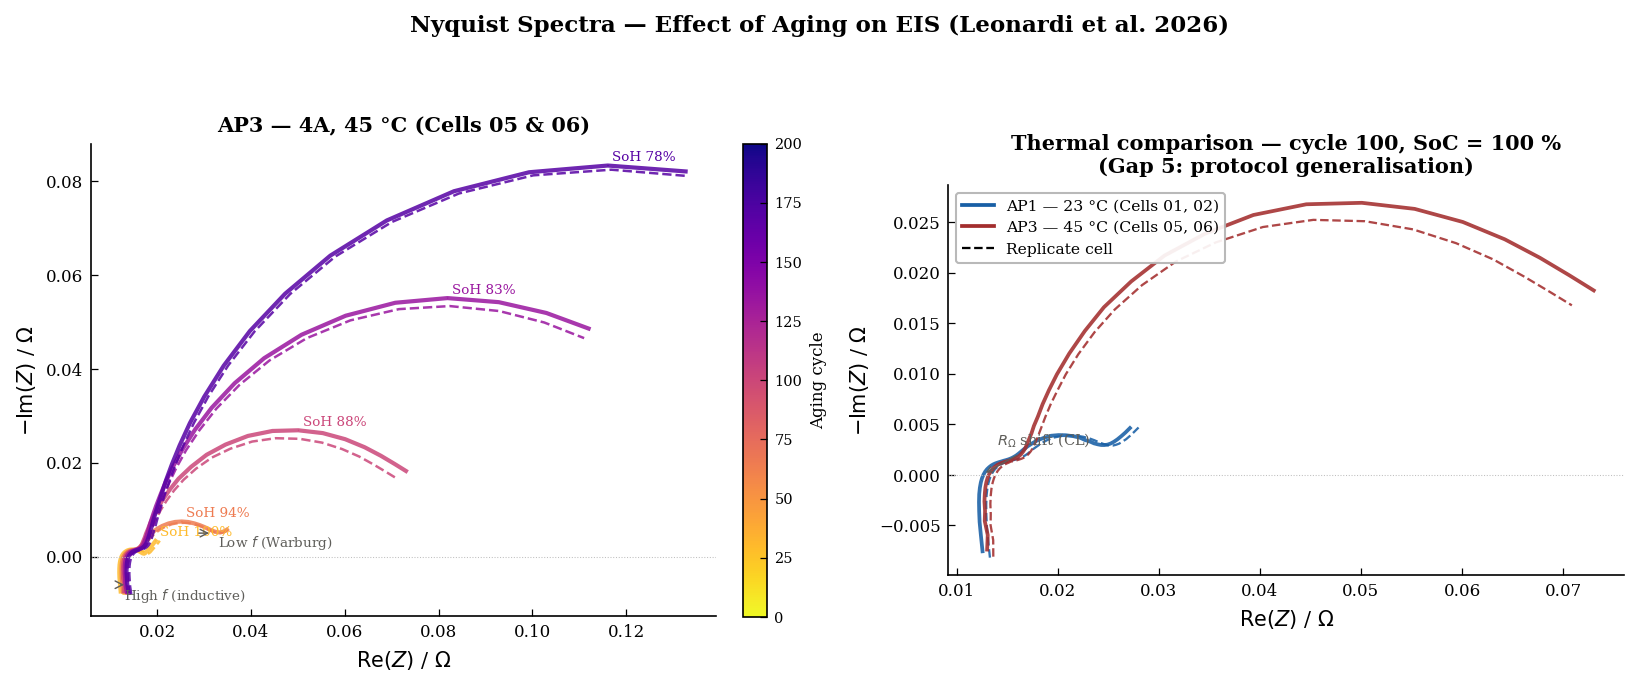

Saved: nyquist_aging_thermal.pdf / .png


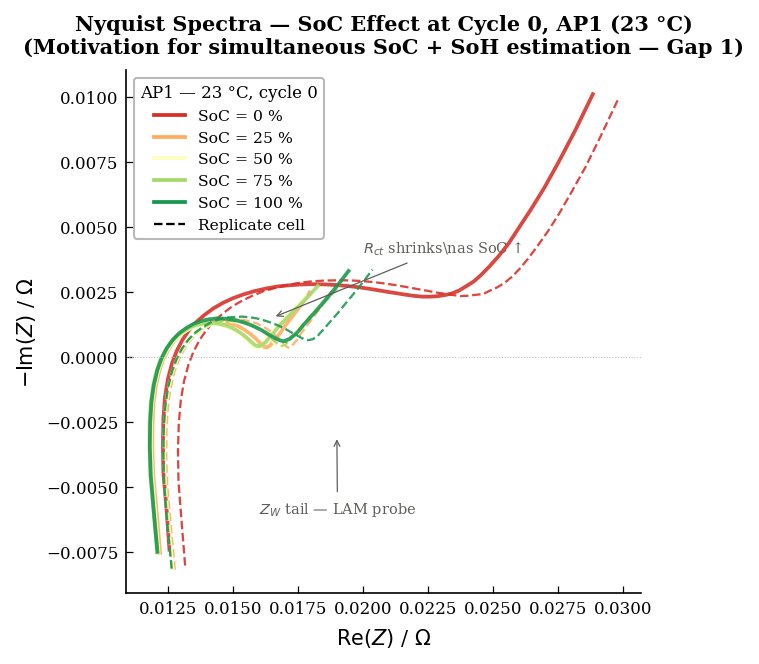

Saved: nyquist_soc_effect.pdf / .png


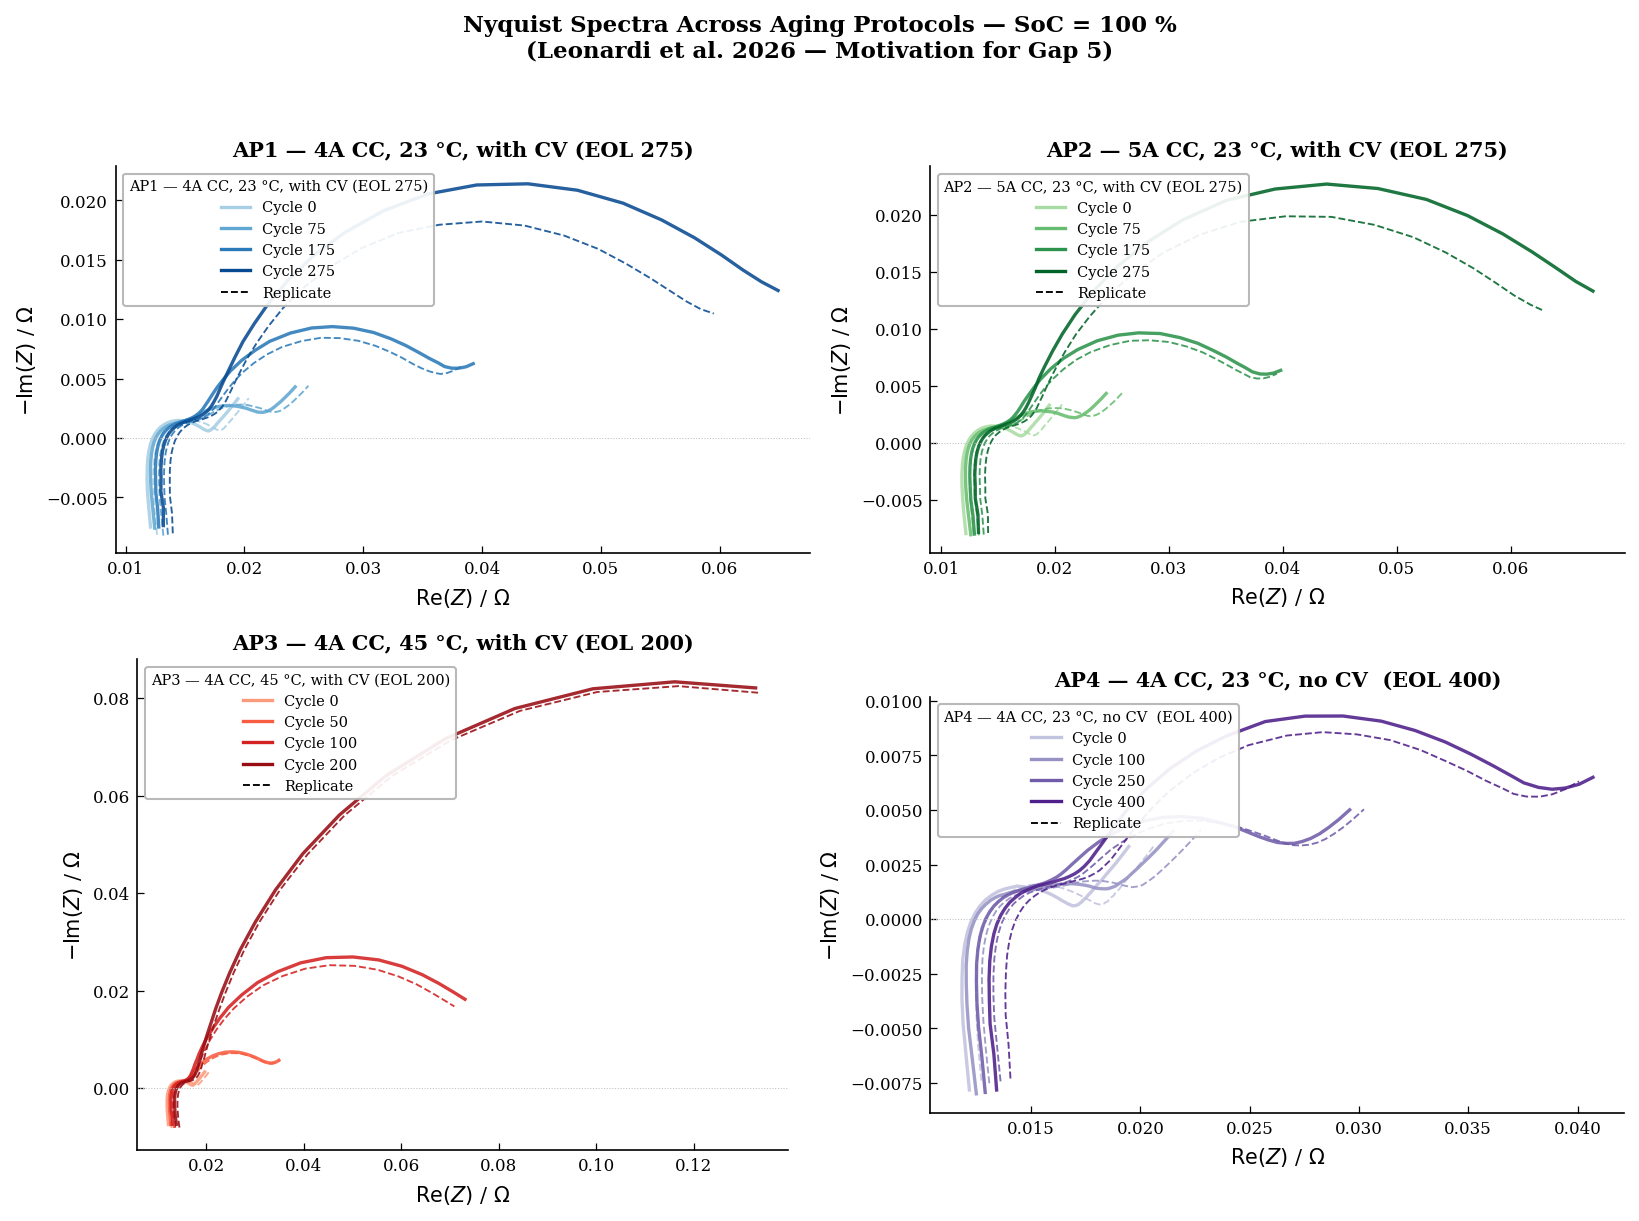

Saved: nyquist_4protocols.pdf / .png


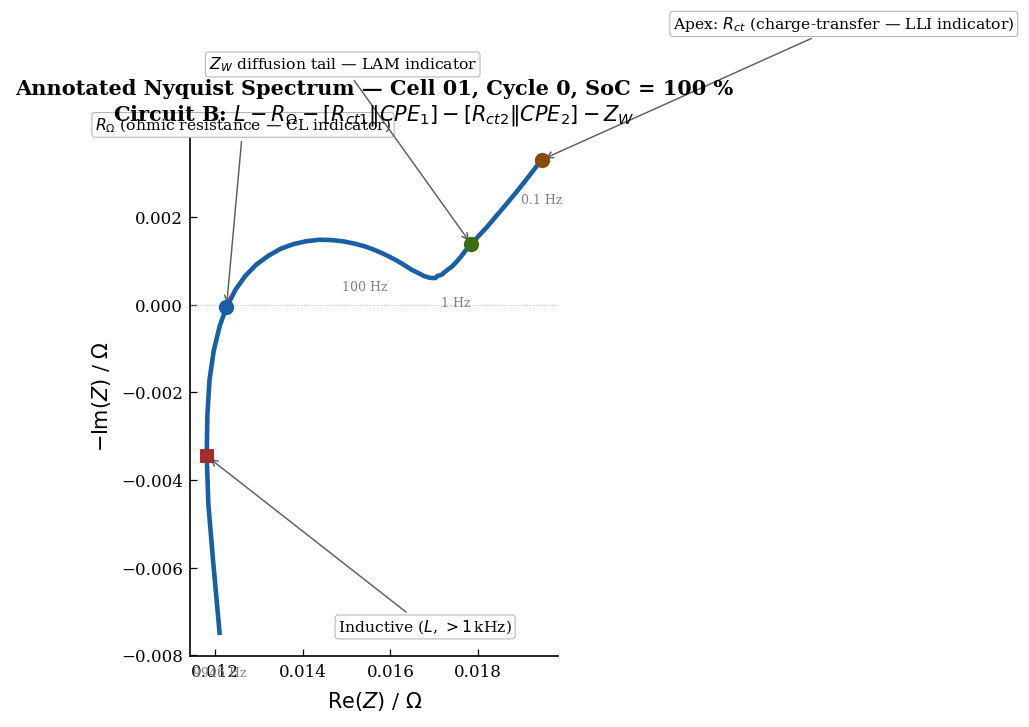

Saved: nyquist_annotated_single.pdf / .png


In [13]:
# ============================================================
# PHASE 1.5 — NYQUIST PLOTS (Publication Quality)
# For thesis and Q1 paper — Leonardi et al. 2026 dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as ticker

# ── Load the final dataset ──────────────────────────────────
data       = np.load('leonardi_final.npz', allow_pickle=True)
X_seq      = data['X_seq']        # (488, 51, 3)  [Re_Z, neg_Im_Z, log10f]
y_SoC      = data['y_SoC']
y_SoH      = data['y_SoH']
cell_ids   = data['cell_ids']
protocols  = data['protocols']
cycles     = data['cycles']
freqs      = data['freqs']        # (51,) Hz, sorted descending

# Helper — extract one spectrum
def get_spectrum(cell, cycle, soc):
    mask = (cell_ids == cell) & (cycles == cycle) & (y_SoC == soc)
    if mask.sum() == 0:
        return None, None
    idx   = np.where(mask)[0][0]
    Re    = X_seq[idx, :, 0]         # Re(Z)
    negIm = X_seq[idx, :, 1]         # -Im(Z)
    return Re, negIm

# ── Global style ────────────────────────────────────────────
plt.rcParams.update({
    'font.family'        : 'DejaVu Serif',
    'font.size'          : 9,
    'axes.labelsize'     : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.linewidth'     : 0.8,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'xtick.direction'    : 'in',
    'ytick.direction'    : 'in',
    'xtick.major.width'  : 0.6,
    'ytick.major.width'  : 0.6,
    'legend.fontsize'    : 8,
    'legend.framealpha'  : 0.92,
    'legend.edgecolor'   : '0.7',
    'figure.dpi'         : 150,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

BLUE   = '#185FA5'
GREEN  = '#3B6D11'
RED    = '#A32D2D'
ORANGE = '#854F0B'
PURPLE = '#534AB7'
GRAY   = '#5F5E5A'

# ============================================================
# FIGURE 1 — SoH degradation across aging (AP3, 45°C)
#            one curve per checkup cycle, SoC = 100%
# ============================================================

fig1, axes1 = plt.subplots(1, 2, figsize=(11, 4.5))
fig1.suptitle(
    'Nyquist Spectra — Effect of Aging on EIS (Leonardi et al. 2026)',
    fontsize=11, fontweight='bold', y=1.01
)

# — Left: AP3 (45°C), cells 5 & 6, SoC=100 —
ax = axes1[0]
cycles_ap3 = [0, 50, 100, 150, 200]
cmap_ap3   = plt.cm.plasma_r(np.linspace(0.15, 0.85, len(cycles_ap3)))

for i, cyc in enumerate(cycles_ap3):
    for cell in [5, 6]:
        Re, negIm = get_spectrum(cell, cyc, 100)
        if Re is None:
            continue
        soh_val = y_SoH[(cell_ids == cell) & (cycles == cyc) & (y_SoC == 100)][0]
        lw  = 2.0 if cell == 5 else 1.2
        ls  = '-'  if cell == 5 else '--'
        ax.plot(Re, negIm, color=cmap_ap3[i], lw=lw, ls=ls, alpha=0.85)
        if cell == 5:           # annotate SoH on primary cell only
            peak_idx = np.argmax(negIm)
            ax.annotate(
                f'SoH {soh_val:.0f}%',
                xy=(Re[peak_idx], negIm[peak_idx]),
                xytext=(Re[peak_idx] + 0.001, negIm[peak_idx] + 0.001),
                fontsize=6.5, color=cmap_ap3[i],
                arrowprops=dict(arrowstyle='-', color=cmap_ap3[i], lw=0.5)
            )

# Frequency region annotations (arrows)
ax.annotate('', xy=(0.0123, -0.006), xytext=(0.013, -0.006),
            arrowprops=dict(arrowstyle='<-', color=GRAY, lw=0.7))
ax.text(0.013, -0.0065, 'High $f$ (inductive)', fontsize=6.5, color=GRAY, va='top')
ax.annotate('', xy=(0.032, 0.005), xytext=(0.028, 0.005),
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.7))
ax.text(0.033, 0.0048, 'Low $f$ (Warburg)', fontsize=6.5, color=GRAY, va='top')

ax.set_xlabel(r'$\mathrm{Re}(Z)$ / $\Omega$')
ax.set_ylabel(r'$-\mathrm{Im}(Z)$ / $\Omega$')
ax.set_title('AP3 — 4A, 45 °C (Cells 05 & 06)', pad=6)
ax.set_aspect('equal')
ax.axhline(0, color='0.75', lw=0.5, ls=':')

# Colorbar for cycles
sm = plt.cm.ScalarMappable(cmap='plasma_r',
     norm=plt.Normalize(vmin=0, vmax=200))
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label('Aging cycle', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# — Right: AP1 vs AP3 at cycle 100, SoC=100 —
ax = axes1[1]

for cell, color, lbl in [(1, BLUE, 'AP1 — 4A 23°C Cell 01'),
                          (2, BLUE, 'AP1 — 4A 23°C Cell 02'),
                          (5, RED,  'AP3 — 4A 45°C Cell 05'),
                          (6, RED,  'AP3 — 4A 45°C Cell 06')]:
    Re, negIm = get_spectrum(cell, 100, 100)
    if Re is None:
        continue
    lw = 1.8 if cell in [1, 5] else 1.1
    ls = '-'  if cell in [1, 5] else '--'
    ax.plot(Re, negIm, color=color, lw=lw, ls=ls, alpha=0.88)

legend_handles = [
    Line2D([0], [0], color=BLUE, lw=1.8, label='AP1 — 23 °C (Cells 01, 02)'),
    Line2D([0], [0], color=RED,  lw=1.8, label='AP3 — 45 °C (Cells 05, 06)'),
    Line2D([0], [0], color='k',  lw=1.1, ls='--', label='Replicate cell'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=7.5)
ax.set_xlabel(r'$\mathrm{Re}(Z)$ / $\Omega$')
ax.set_ylabel(r'$-\mathrm{Im}(Z)$ / $\Omega$')
ax.set_title('Thermal comparison — cycle 100, SoC = 100 %\n(Gap 5: protocol generalisation)', pad=6)
ax.set_aspect('equal')
ax.axhline(0, color='0.75', lw=0.5, ls=':')

# Annotation: R_ohm shift
ax.annotate(
    r'$R_\Omega$ shift (CL)', xy=(0.0125, 0), xytext=(0.014, 0.003),
    fontsize=7, color=GRAY,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.6)
)

fig1.tight_layout()
fig1.savefig('nyquist_aging_thermal.pdf')
fig1.savefig('nyquist_aging_thermal.png', dpi=300)
plt.show()
print("Saved: nyquist_aging_thermal.pdf / .png")


# ============================================================
# FIGURE 2 — SoC effect at fixed cycle (cycle 0, AP1)
#            5 SoC levels × 2 cells
# ============================================================

fig2, ax = plt.subplots(figsize=(6.5, 4.5))

soc_levels = [0, 25, 50, 75, 100]
cmap_soc   = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(soc_levels)))

for j, soc in enumerate(soc_levels):
    for cell, ls in [(1, '-'), (2, '--')]:
        Re, negIm = get_spectrum(cell, 0, soc)
        if Re is None:
            continue
        ax.plot(Re, negIm, color=cmap_soc[j], lw=1.8 if ls == '-' else 1.1,
                ls=ls, alpha=0.88)

# Custom legend: SoC gradient + linestyle
soc_handles = [
    Line2D([0], [0], color=cmap_soc[j], lw=1.8, label=f'SoC = {soc} %')
    for j, soc in enumerate(soc_levels)
]
soc_handles.append(
    Line2D([0], [0], color='k', lw=1.1, ls='--', label='Replicate cell')
)
ax.legend(handles=soc_handles, loc='upper left', fontsize=7.5,
          title='AP1 — 23 °C, cycle 0', title_fontsize=8)

# Annotate SoC-sensitive features
ax.annotate(
    r'$R_{ct}$ shrinks\nas SoC ↑',
    xy=(0.0165, 0.0015), xytext=(0.020, 0.004),
    fontsize=7, color=GRAY,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.6)
)
ax.annotate(
    r'$Z_W$ tail — LAM probe',
    xy=(0.019, -0.003), xytext=(0.016, -0.006),
    fontsize=7, color=GRAY,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.6)
)

ax.set_xlabel(r'$\mathrm{Re}(Z)$ / $\Omega$')
ax.set_ylabel(r'$-\mathrm{Im}(Z)$ / $\Omega$')
ax.set_title(
    'Nyquist Spectra — SoC Effect at Cycle 0, AP1 (23 °C)\n'
    '(Motivation for simultaneous SoC + SoH estimation — Gap 1)',
    fontsize=10, fontweight='bold', pad=8
)
ax.set_aspect('equal')
ax.axhline(0, color='0.75', lw=0.5, ls=':')

fig2.tight_layout()
fig2.savefig('nyquist_soc_effect.pdf')
fig2.savefig('nyquist_soc_effect.png', dpi=300)
plt.show()
print("Saved: nyquist_soc_effect.pdf / .png")


# ============================================================
# FIGURE 3 — 4-protocol comparison at same cycle & SoC
#            (Gap 4: multi-protocol validation)
# ============================================================

fig3, axes3 = plt.subplots(2, 2, figsize=(11, 8), sharex=False, sharey=False)
fig3.suptitle(
    'Nyquist Spectra Across Aging Protocols — SoC = 100 %\n'
    '(Leonardi et al. 2026 — Motivation for Gap 5)',
    fontsize=11, fontweight='bold', y=1.01
)

proto_info = {
    'AP1': {'cells': [1, 2], 'color': BLUE,   'cycles': [0, 75, 175, 275], 'ax_idx': (0, 0)},
    'AP2': {'cells': [3, 4], 'color': GREEN,  'cycles': [0, 75, 175, 275], 'ax_idx': (0, 1)},
    'AP3': {'cells': [5, 6], 'color': RED,    'cycles': [0, 50, 100, 200], 'ax_idx': (1, 0)},
    'AP4': {'cells': [7, 8], 'color': PURPLE, 'cycles': [0, 100, 250, 400], 'ax_idx': (1, 1)},
}
proto_labels = {
    'AP1': 'AP1 — 4A CC, 23 °C, with CV (EOL 275)',
    'AP2': 'AP2 — 5A CC, 23 °C, with CV (EOL 275)',
    'AP3': 'AP3 — 4A CC, 45 °C, with CV (EOL 200)',
    'AP4': 'AP4 — 4A CC, 23 °C, no CV  (EOL 400)',
}

for prot, info in proto_info.items():
    ax   = axes3[info['ax_idx']]
    col  = info['color']
    cycs = info['cycles']
    cmap_p = plt.cm.Blues if prot == 'AP1' else (
             plt.cm.Greens if prot == 'AP2' else (
             plt.cm.Reds   if prot == 'AP3' else
             plt.cm.Purples))
    shades = cmap_p(np.linspace(0.35, 0.9, len(cycs)))

    for k, cyc in enumerate(cycs):
        for cell_id, ls in zip(info['cells'], ['-', '--']):
            Re, negIm = get_spectrum(cell_id, cyc, 100)
            if Re is None:
                continue
            ax.plot(Re, negIm, color=shades[k], lw=1.6 if ls == '-' else 0.9,
                    ls=ls, alpha=0.88)

    handles = [
        Line2D([0], [0], color=shades[k], lw=1.6, label=f'Cycle {cyc}')
        for k, cyc in enumerate(cycs)
    ]
    handles.append(Line2D([0], [0], color='k', lw=0.9, ls='--', label='Replicate'))
    ax.legend(handles=handles, fontsize=7, title=proto_labels[prot],
              title_fontsize=7, loc='upper left')
    ax.set_xlabel(r'$\mathrm{Re}(Z)$ / $\Omega$')
    ax.set_ylabel(r'$-\mathrm{Im}(Z)$ / $\Omega$')
    ax.set_title(f'{prot} — {proto_labels[prot].split("—")[1].strip()}', pad=5)
    ax.set_aspect('equal')
    ax.axhline(0, color='0.75', lw=0.5, ls=':')

fig3.tight_layout()
fig3.savefig('nyquist_4protocols.pdf')
fig3.savefig('nyquist_4protocols.png', dpi=300)
plt.show()
print("Saved: nyquist_4protocols.pdf / .png")


# ============================================================
# FIGURE 4 — Annotated single spectrum (thesis-ready explainer)
#            ECM element mapping visible on Nyquist plane
# ============================================================

fig4, ax = plt.subplots(figsize=(7, 5))

Re, negIm = get_spectrum(1, 0, 100)   # Cell 01, fresh, fully charged

ax.plot(Re, negIm, color=BLUE, lw=2.2, zorder=3)

# Mark key frequency points
# High-freq intercept (Re-axis crossing ~ R_ohm)
hf_idx = np.argmin(np.abs(negIm))        # closest to zero imaginary
ax.scatter(Re[hf_idx], negIm[hf_idx], color=BLUE, s=40, zorder=5)
ax.annotate(
    r'$R_\Omega$ (ohmic resistance — CL indicator)',
    xy=(Re[hf_idx], negIm[hf_idx]), xytext=(Re[hf_idx] - 0.003, 0.004),
    fontsize=7.5,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.7),
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', lw=0.5)
)

# Semicircle apex ~ R_ct
apex_idx = np.argmax(negIm)
ax.scatter(Re[apex_idx], negIm[apex_idx], color=ORANGE, s=40, zorder=5)
ax.annotate(
    r'Apex: $R_{ct}$ (charge-transfer — LLI indicator)',
    xy=(Re[apex_idx], negIm[apex_idx]),
    xytext=(Re[apex_idx] + 0.003, negIm[apex_idx] + 0.003),
    fontsize=7.5,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.7),
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', lw=0.5)
)

# Low-freq tail onset (Warburg)
lf_idx = -8    # last few points
ax.scatter(Re[lf_idx], negIm[lf_idx], color=GREEN, s=40, zorder=5)
ax.annotate(
    r'$Z_W$ diffusion tail — LAM indicator',
    xy=(Re[lf_idx], negIm[lf_idx]),
    xytext=(Re[lf_idx] - 0.006, negIm[lf_idx] + 0.004),
    fontsize=7.5,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.7),
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', lw=0.5)
)

# Inductive region label
ind_idx = 3     # top high-freq inductive points
ax.scatter(Re[ind_idx], negIm[ind_idx], color=RED, s=30, zorder=5, marker='s')
ax.annotate(
    r'Inductive ($L$, $>1\,$kHz)',
    xy=(Re[ind_idx], negIm[ind_idx]),
    xytext=(Re[ind_idx] + 0.003, negIm[ind_idx] - 0.004),
    fontsize=7.5,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.7),
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', lw=0.5)
)

# Frequency labels along the curve
for label_freq, label_txt in [(9946, '9946 Hz'), (100, '100 Hz'),
                               (1.0, '1 Hz'), (0.1, '0.1 Hz')]:
    idx = np.argmin(np.abs(freqs - label_freq))
    ax.text(Re[idx], negIm[idx] - 0.001, label_txt,
            fontsize=6, color='0.5', ha='center')

ax.set_xlabel(r'$\mathrm{Re}(Z)$ / $\Omega$', fontsize=10)
ax.set_ylabel(r'$-\mathrm{Im}(Z)$ / $\Omega$', fontsize=10)
ax.set_title(
    'Annotated Nyquist Spectrum — Cell 01, Cycle 0, SoC = 100 %\n'
    r'Circuit B: $L - R_\Omega - [R_{ct1} \| CPE_1] - [R_{ct2} \| CPE_2] - Z_W$',
    fontsize=10, fontweight='bold', pad=8
)
ax.set_aspect('equal')
ax.axhline(0, color='0.75', lw=0.5, ls=':')

fig4.tight_layout()
fig4.savefig('nyquist_annotated_single.pdf')
fig4.savefig('nyquist_annotated_single.png', dpi=300)
plt.show()
print("Saved: nyquist_annotated_single.pdf / .png")

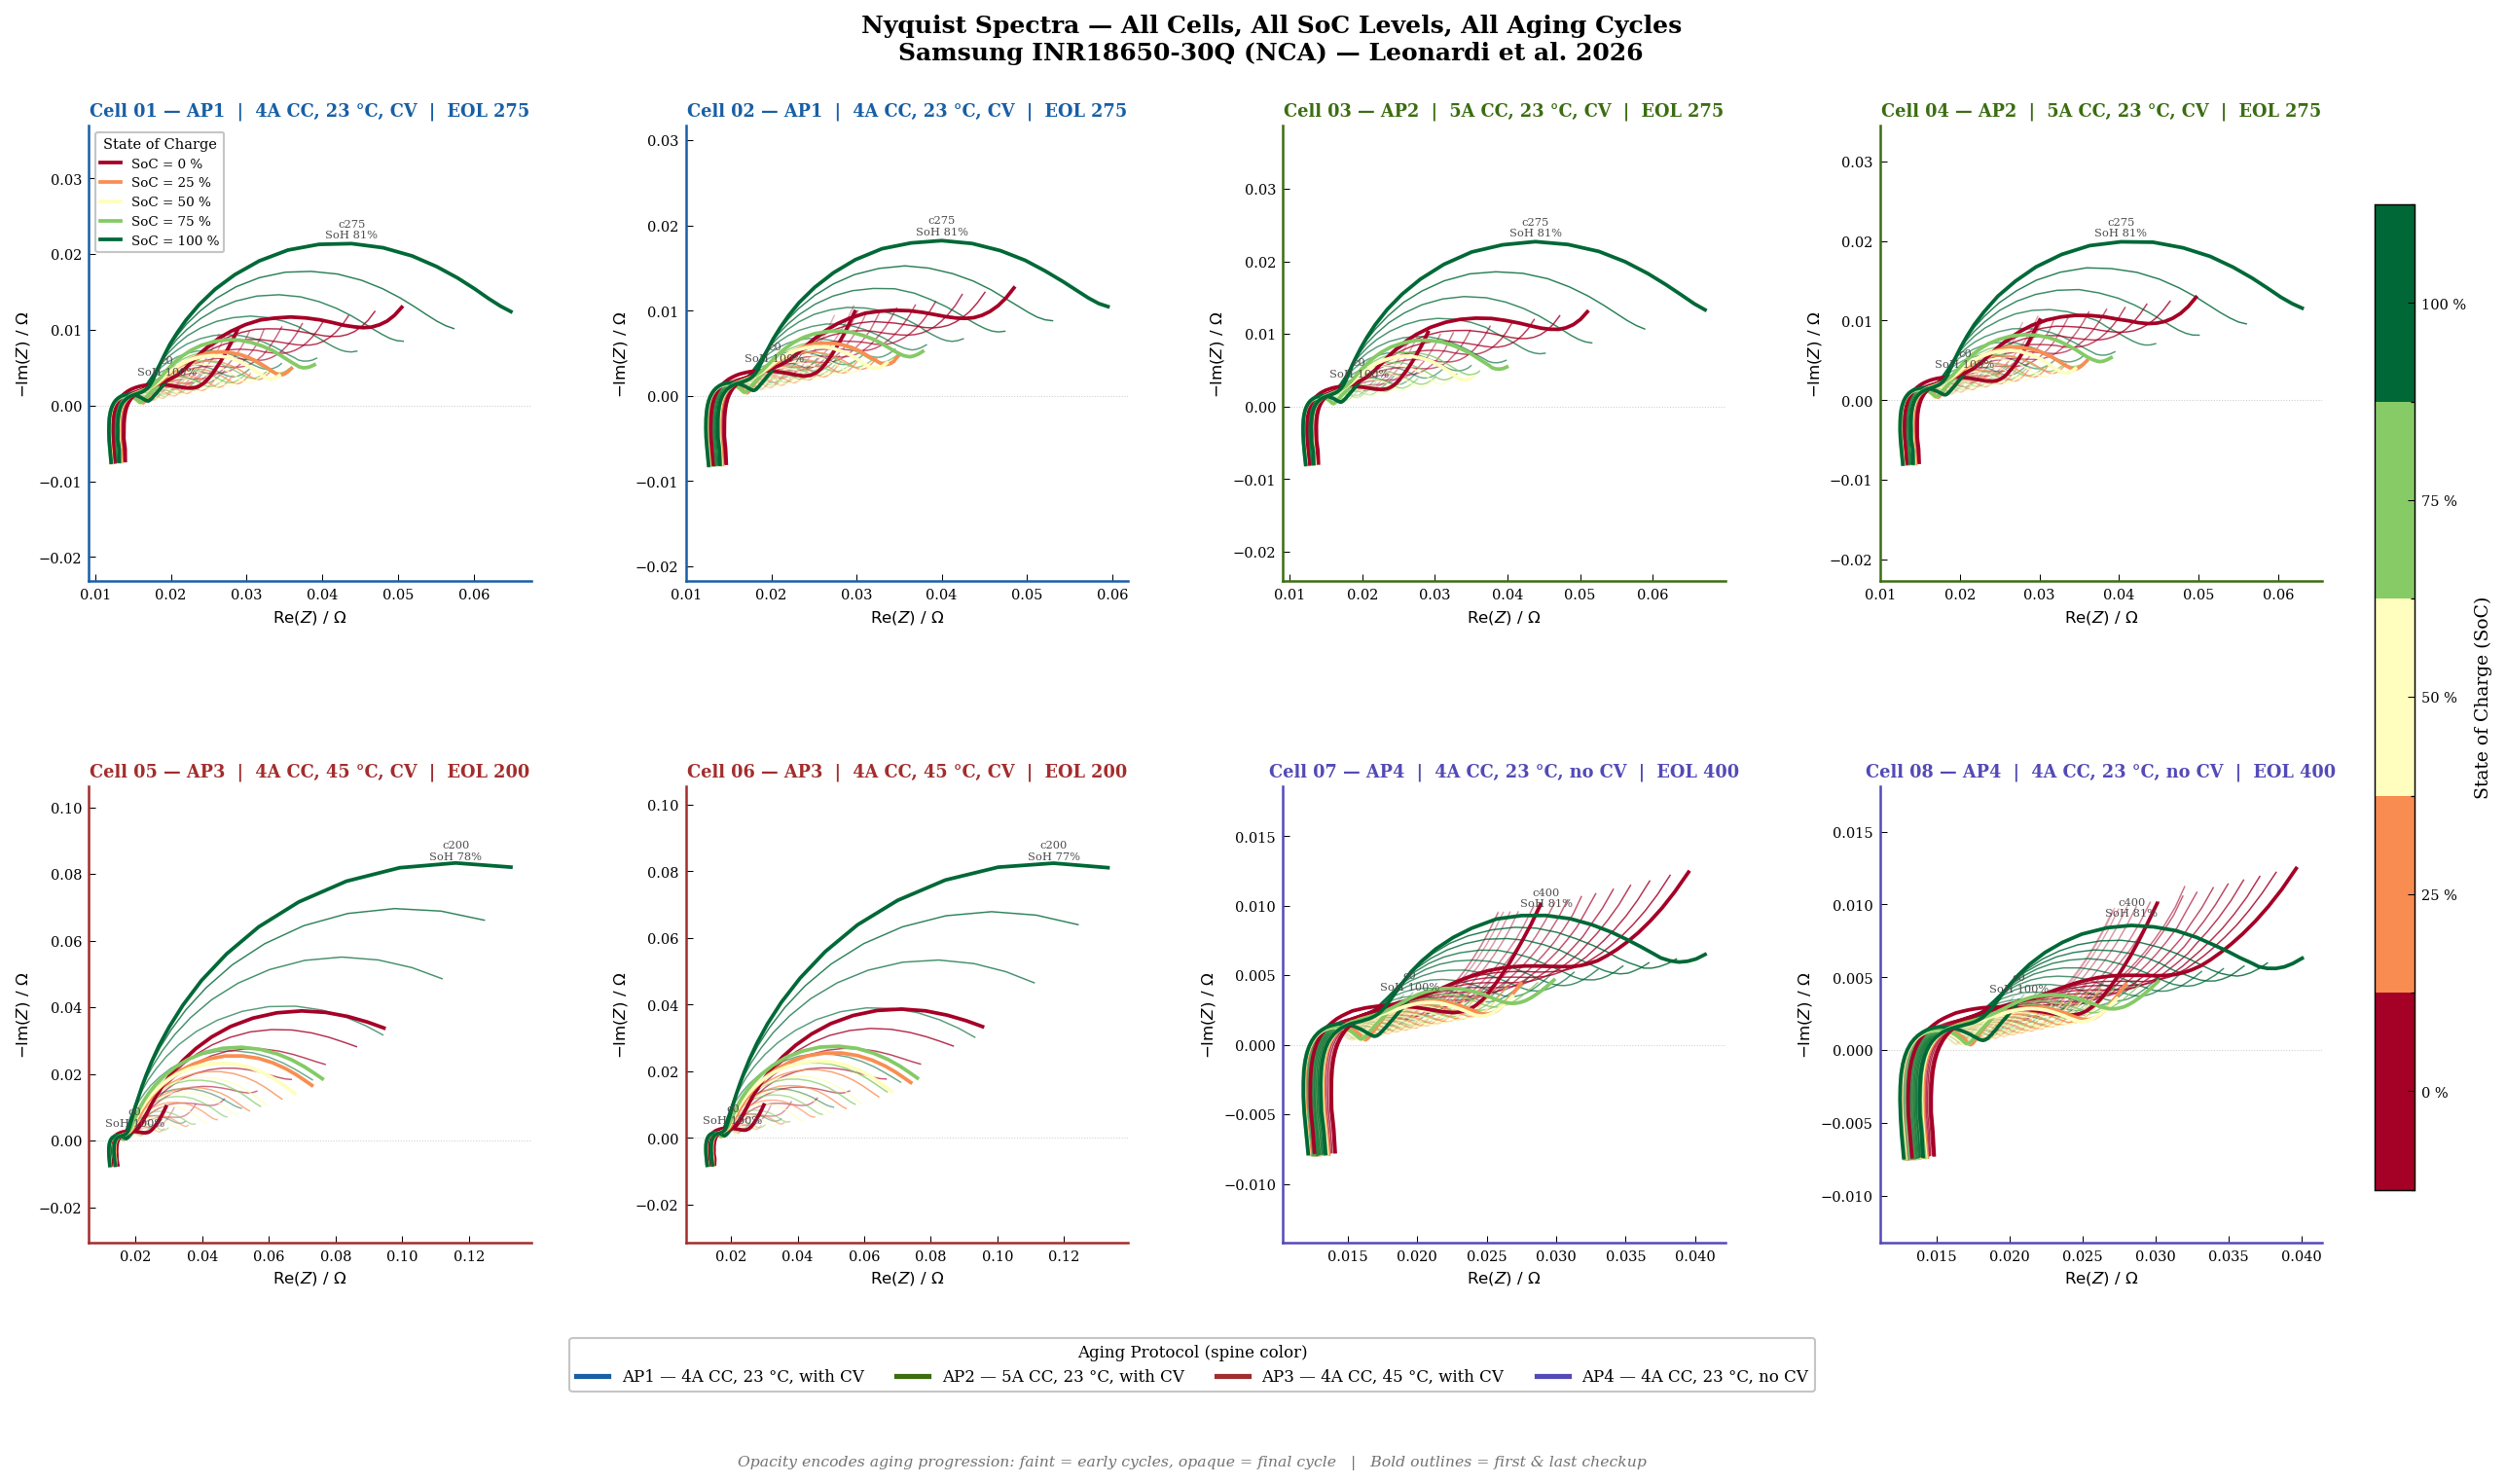

Saved: nyquist_all_cells_soc.pdf / .png


In [16]:
# ============================================================
# NYQUIST PLOTS — All 8 Cells × All SoC Levels
# 8 subplots, one per cell, colored by SoC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ── Load dataset ────────────────────────────────────────────
data     = np.load('leonardi_final.npz', allow_pickle=True)
X_seq    = data['X_seq']       # (488, 51, 3)
y_SoC    = data['y_SoC']
y_SoH    = data['y_SoH']
cell_ids = data['cell_ids']
cycles   = data['cycles']
freqs    = data['freqs']

# ── Cell metadata ───────────────────────────────────────────
cell_meta = {
    1: {'protocol': 'AP1', 'label': 'Cell 01 — AP1  |  4A CC, 23 °C, CV  |  EOL 275'},
    2: {'protocol': 'AP1', 'label': 'Cell 02 — AP1  |  4A CC, 23 °C, CV  |  EOL 275'},
    3: {'protocol': 'AP2', 'label': 'Cell 03 — AP2  |  5A CC, 23 °C, CV  |  EOL 275'},
    4: {'protocol': 'AP2', 'label': 'Cell 04 — AP2  |  5A CC, 23 °C, CV  |  EOL 275'},
    5: {'protocol': 'AP3', 'label': 'Cell 05 — AP3  |  4A CC, 45 °C, CV  |  EOL 200'},
    6: {'protocol': 'AP3', 'label': 'Cell 06 — AP3  |  4A CC, 45 °C, CV  |  EOL 200'},
    7: {'protocol': 'AP4', 'label': 'Cell 07 — AP4  |  4A CC, 23 °C, no CV  |  EOL 400'},
    8: {'protocol': 'AP4', 'label': 'Cell 08 — AP4  |  4A CC, 23 °C, no CV  |  EOL 400'},
}

# Protocol accent colors (border + title)
proto_colors = {
    'AP1': '#185FA5',   # blue
    'AP2': '#3B6D11',   # green
    'AP3': '#A32D2D',   # red
    'AP4': '#534AB7',   # purple
}

# SoC colormap: red (0%) → yellow → green (100%)
SOC_LEVELS = [0, 25, 50, 75, 100]
soc_cmap   = cm.RdYlGn
soc_colors = {soc: soc_cmap(i / (len(SOC_LEVELS) - 1))
              for i, soc in enumerate(SOC_LEVELS)}

# ── Global style ────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Serif',
    'font.size'         : 8,
    'axes.labelsize'    : 8,
    'axes.titlesize'    : 8.5,
    'axes.titleweight'  : 'bold',
    'axes.linewidth'    : 0.7,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'legend.fontsize'   : 7,
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '0.75',
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# ── Figure layout ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    'Nyquist Spectra — All Cells, All SoC Levels, All Aging Cycles\n'
    'Samsung INR18650-30Q (NCA) — Leonardi et al. 2026',
    fontsize=12, fontweight='bold', y=1.015
)
axes_flat = axes.flatten()   # [Cell01 … Cell08]

for cell_id in range(1, 9):
    ax   = axes_flat[cell_id - 1]
    meta = cell_meta[cell_id]
    prot = meta['protocol']
    pcol = proto_colors[prot]

    # Gather all indices for this cell
    cell_mask = (cell_ids == cell_id)
    cell_cycles = np.unique(cycles[cell_mask])

    # ── Plot every spectrum, colored by SoC ─────────────────
    for cyc in cell_cycles:
        for soc in SOC_LEVELS:
            mask = cell_mask & (cycles == cyc) & (y_SoC == soc)
            if mask.sum() == 0:
                continue
            idx   = np.where(mask)[0][0]
            Re    = X_seq[idx, :, 0]
            negIm = X_seq[idx, :, 1]

            # Fade older cycles: alpha ∝ cycle progression
            max_cyc = cell_cycles.max()
            alpha   = 0.25 + 0.65 * (cyc / max_cyc) if max_cyc > 0 else 0.7

            ax.plot(Re, negIm,
                    color=soc_colors[soc],
                    lw=0.7,
                    alpha=alpha,
                    rasterized=True)   # speeds up PDF rendering

    # ── Highlight first and last checkup ────────────────────
    for cyc, lw, zo, ann in [(cell_cycles[0],  1.8, 4, True),
                              (cell_cycles[-1], 1.8, 4, True)]:
        for soc in SOC_LEVELS:
            mask = cell_mask & (cycles == cyc) & (y_SoC == soc)
            if mask.sum() == 0:
                continue
            idx   = np.where(mask)[0][0]
            Re    = X_seq[idx, :, 0]
            negIm = X_seq[idx, :, 1]
            ax.plot(Re, negIm, color=soc_colors[soc], lw=lw, zorder=zo,
                    alpha=1.0)

        if ann:
            # Label cycle on the SoC=100 spectrum
            mask100 = cell_mask & (cycles == cyc) & (y_SoC == 100)
            if mask100.sum() > 0:
                idx100 = np.where(mask100)[0][0]
                soh_v  = y_SoH[idx100]
                Re_lab = X_seq[idx100, :, 0]
                nI_lab = X_seq[idx100, :, 1]
                apex   = np.argmax(nI_lab)
                tag    = f'c{cyc}\nSoH {soh_v:.0f}%'
                ax.text(Re_lab[apex], nI_lab[apex] + 0.0005,
                        tag, fontsize=5.5, ha='center', va='bottom',
                        color='0.3', zorder=6)

    # ── Reference line at Im=0 ──────────────────────────────
    ax.axhline(0, color='0.8', lw=0.5, ls=':', zorder=1)

    # ── Axis labels ─────────────────────────────────────────
    ax.set_xlabel(r'$\mathrm{Re}(Z)\ /\ \Omega$', labelpad=3)
    ax.set_ylabel(r'$-\mathrm{Im}(Z)\ /\ \Omega$', labelpad=3)
    ax.set_aspect('equal', adjustable='datalim')

    # ── Title with protocol color accent ────────────────────
    ax.set_title(meta['label'], color=pcol, pad=5)

    # ── Colored spine border matching protocol ───────────────
    for spine in ax.spines.values():
        spine.set_edgecolor(pcol)
        spine.set_linewidth(1.2)

    # ── Per-cell SoC legend (first cell only to save space) ──
    if cell_id == 1:
        soc_handles = [
            Line2D([0], [0], color=soc_colors[s], lw=1.8,
                   label=f'SoC = {s} %')
            for s in SOC_LEVELS
        ]
        ax.legend(handles=soc_handles, loc='upper left',
                  title='State of Charge', title_fontsize=7,
                  fontsize=6.5, handlelength=1.5)

# ── Global SoC colorbar ─────────────────────────────────────

# ── Global SoC colorbar ─────────────────────────────────────
import matplotlib.colors as mcolors

sm = plt.cm.ScalarMappable(
    cmap=soc_cmap,
    norm=mcolors.BoundaryNorm([-12.5, 12.5, 37.5, 62.5, 87.5, 112.5],
                               soc_cmap.N)
)
sm.set_array([])

# Reserve a dedicated axes for the colorbar — no overlap possible
cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.75])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels(['0 %', '25 %', '50 %', '75 %', '100 %'])
cbar.set_label('State of Charge (SoC)', fontsize=9)
cbar.ax.tick_params(labelsize=7)

# ── Protocol legend (bottom center) ─────────────────────────
proto_handles = [
    Line2D([0], [0], color=proto_colors[p], lw=2.5, label=lbl)
    for p, lbl in [
        ('AP1', 'AP1 — 4A CC, 23 °C, with CV'),
        ('AP2', 'AP2 — 5A CC, 23 °C, with CV'),
        ('AP3', 'AP3 — 4A CC, 45 °C, with CV'),
        ('AP4', 'AP4 — 4A CC, 23 °C, no CV'),
    ]
]
fig.legend(handles=proto_handles,
           loc='lower center', ncol=4,
           fontsize=8, framealpha=0.9,
           bbox_to_anchor=(0.47, -0.04),
           title='Aging Protocol (spine color)',
           title_fontsize=8)

# ── Opacity note ────────────────────────────────────────────
fig.text(0.47, -0.09,
         'Opacity encodes aging progression: faint = early cycles, '
         'opaque = final cycle   |   Bold outlines = first & last checkup',
         ha='center', fontsize=7.5, color='0.45', style='italic')

# ── Save ────────────────────────────────────────────────────
# Use subplots_adjust instead of tight_layout to keep manual cbar_ax intact
fig.subplots_adjust(left=0.05, right=0.90, top=0.93, bottom=0.08,
                    wspace=0.35, hspace=0.45)

fig.savefig('nyquist_all_cells_soc.pdf', bbox_inches='tight')
fig.savefig('nyquist_all_cells_soc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: nyquist_all_cells_soc.pdf / .png")

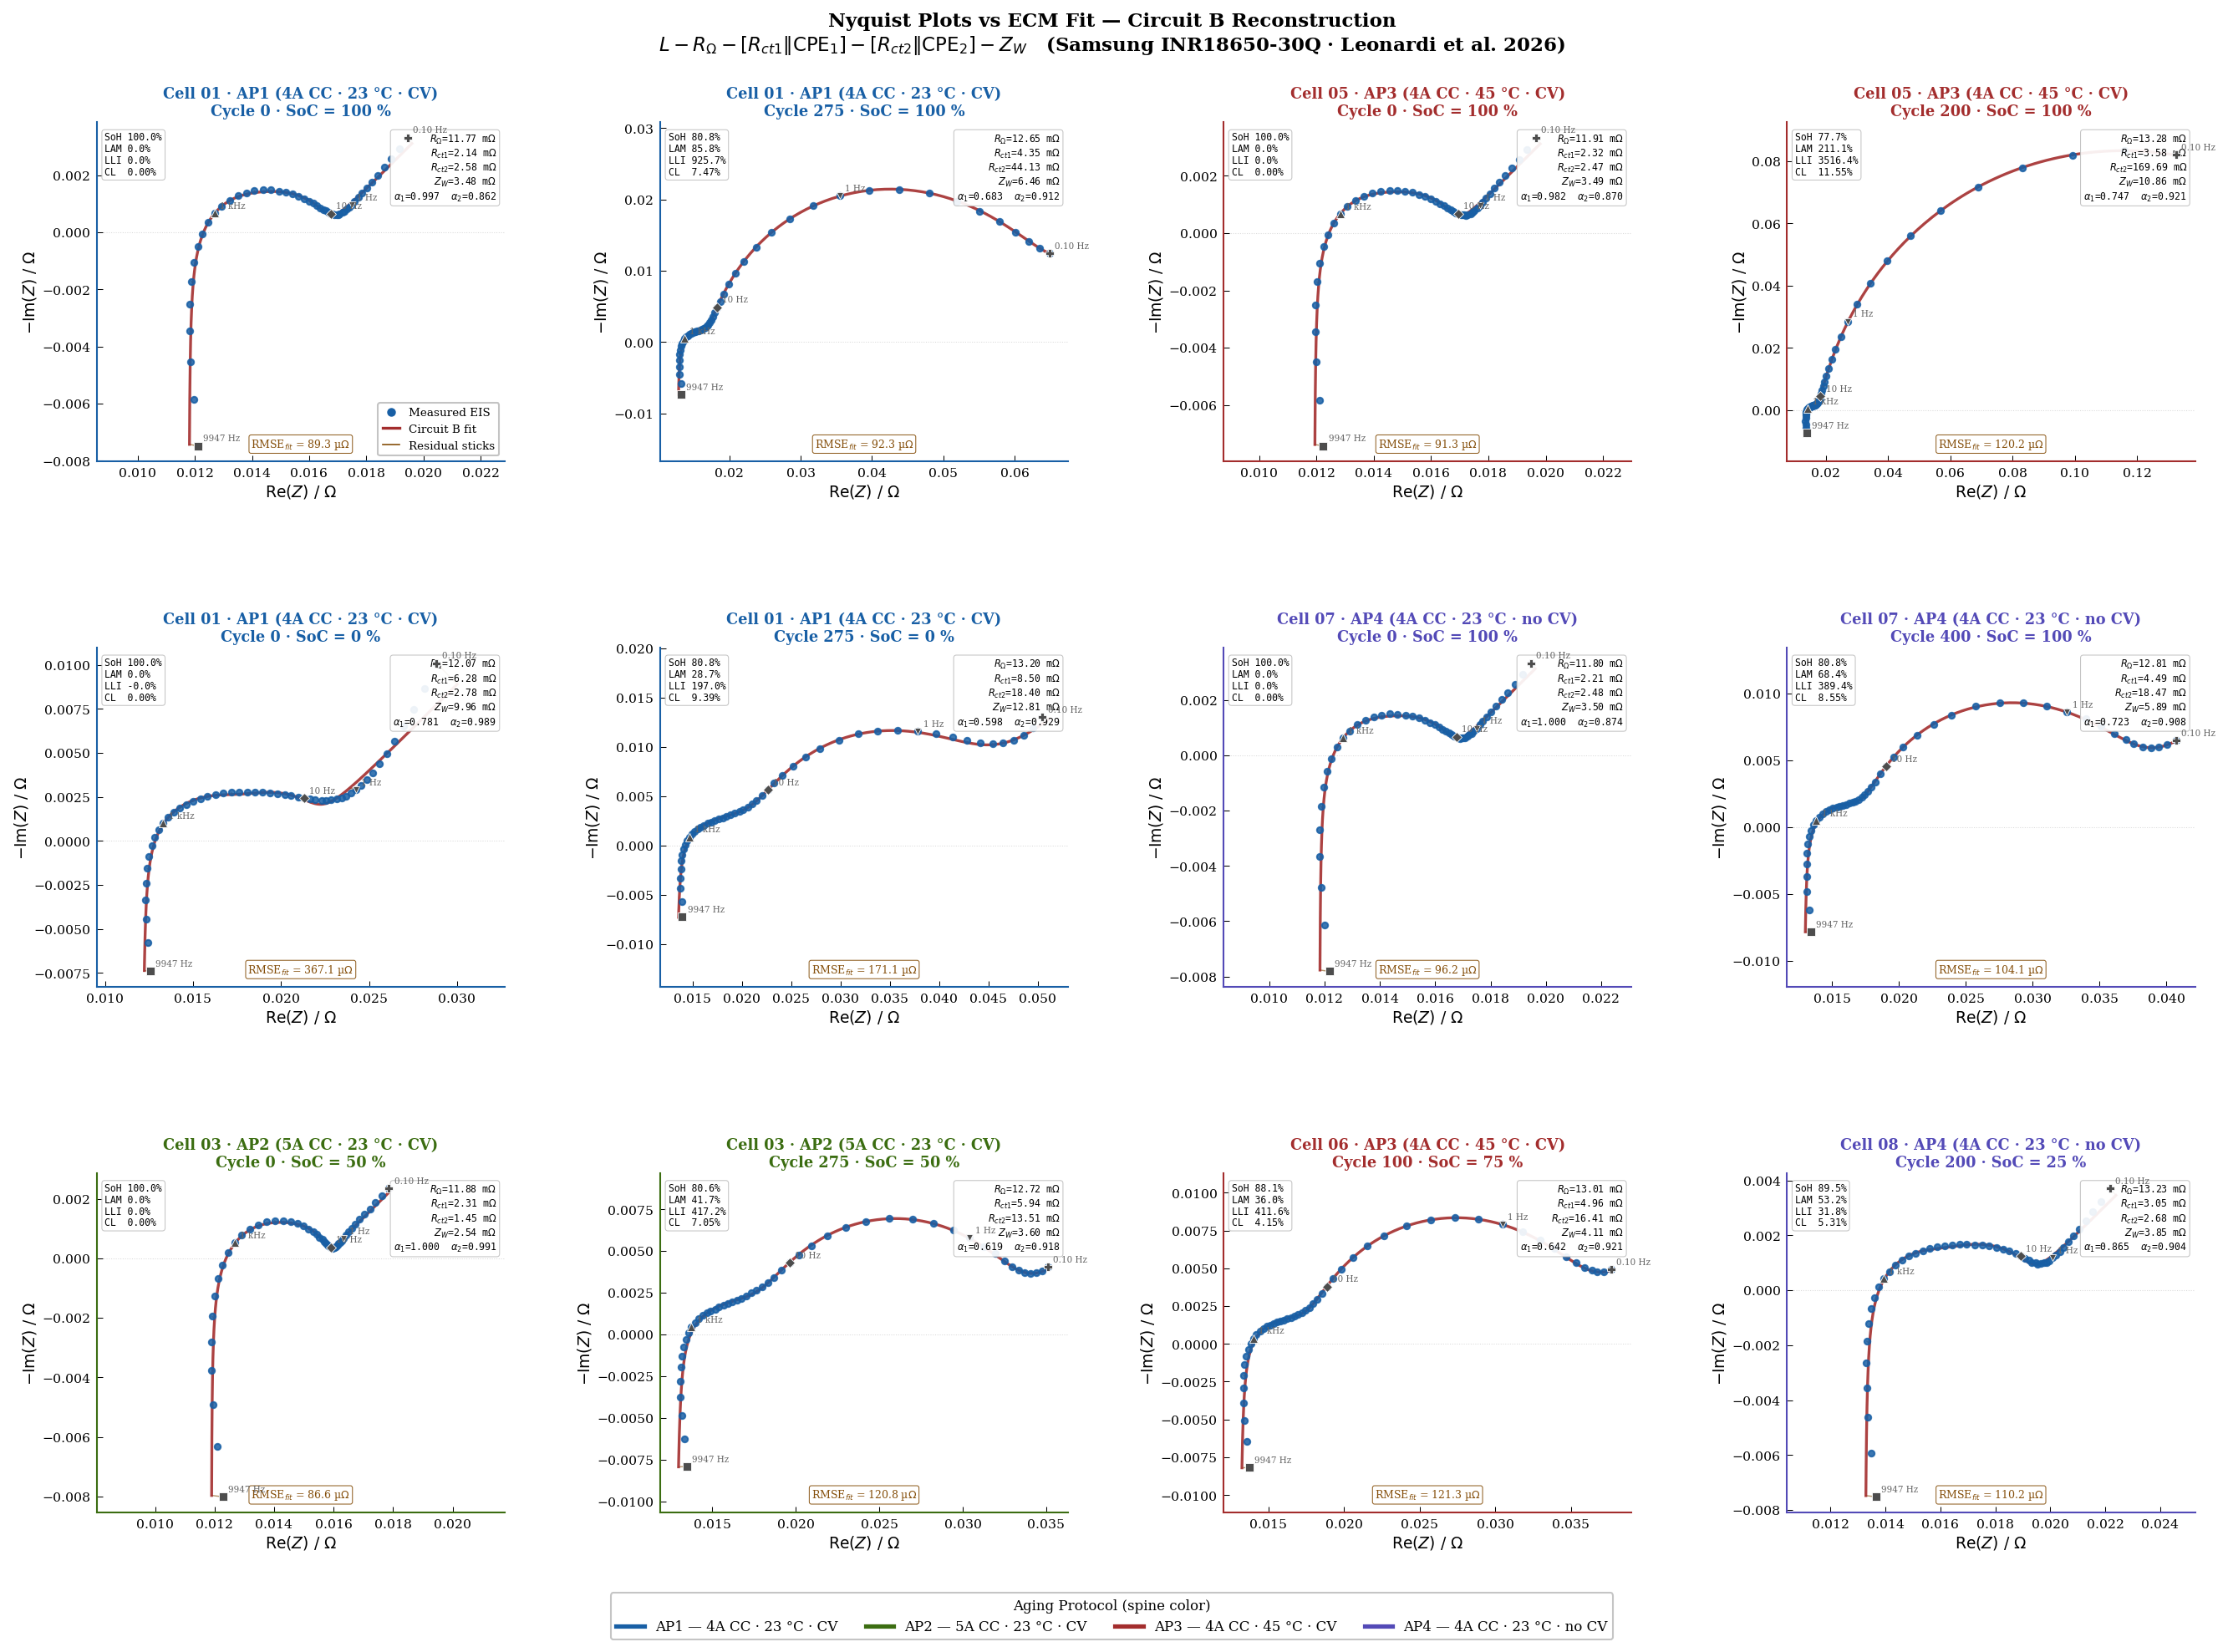

Saved: nyquist_vs_ecm_fit.pdf / .png


In [1]:
# ============================================================
# NYQUIST vs ECM FIT — Measured spectrum overlaid with
# Circuit B reconstruction from fitted parameters
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ── Load dataset ────────────────────────────────────────────
data     = np.load('leonardi_final.npz', allow_pickle=True)
X_seq    = data['X_seq']       # (488, 51, 3) — [Re_Z, neg_Im_Z, log10f]
X_tab    = data['X_tab']       # (488, 9)     — [L, R_ohm, R_ct1, Q1, alpha1,
                               #                  R_ct2, Q2, alpha2, z_w]
y_SoC    = data['y_SoC']
y_SoH    = data['y_SoH']
y_LAM    = data['y_LAM']
y_LLI    = data['y_LLI']
y_CL     = data['y_CL']
cell_ids = data['cell_ids']
cycles   = data['cycles']
freqs    = data['freqs']       # (51,) Hz, descending

# ── Circuit B impedance model ────────────────────────────────
# L - R_ohm - [R_ct1 // CPE1] - [R_ct2 // CPE2] - Z_w
# CPE impedance : Z_CPE = 1 / (Q * (jw)^alpha)
# Warburg       : Z_w   = z_w / sqrt(jw)   [semi-infinite, slope 45°]

def circuit_B(freqs_hz, L, R_ohm, R_ct1, Q1, alpha1,
                              R_ct2, Q2, alpha2, z_w):
    """
    Returns Re(Z) and -Im(Z) arrays for Circuit B
    evaluated at each frequency in freqs_hz.
    """
    w  = 2 * np.pi * freqs_hz          # angular frequency
    jw = 1j * w

    # Inductor
    Z_L = jw * L

    # CPE branches
    Z_CPE1 = 1.0 / (Q1 * (jw ** alpha1))
    Z_CPE2 = 1.0 / (Q2 * (jw ** alpha2))

    # Parallel RC-CPE arcs
    Z_arc1 = (R_ct1 * Z_CPE1) / (R_ct1 + Z_CPE1)
    Z_arc2 = (R_ct2 * Z_CPE2) / (R_ct2 + Z_CPE2)

    # Semi-infinite Warburg
    Z_W = z_w / np.sqrt(jw)

    # Total
    Z_total = Z_L + R_ohm + Z_arc1 + Z_arc2 + Z_W

    return Z_total.real, -Z_total.imag


def get_sample(cell, cyc, soc):
    """Return (Re, negIm, ecm_params, soh, lam, lli, cl) for one sample."""
    mask = (cell_ids == cell) & (cycles == cyc) & (y_SoC == soc)
    if mask.sum() == 0:
        return None
    idx = np.where(mask)[0][0]
    Re    = X_seq[idx, :, 0]
    negIm = X_seq[idx, :, 1]
    # ECM params: [L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, z_w]
    params = X_tab[idx]
    soh = float(y_SoH[idx])
    lam = float(y_LAM[idx])
    lli = float(y_LLI[idx])
    cl  = float(y_CL[idx])
    return Re, negIm, params, soh, lam, lli, cl


# ── Global style ────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Serif',
    'font.size'         : 8,
    'axes.labelsize'    : 9,
    'axes.titlesize'    : 9,
    'axes.titleweight'  : 'bold',
    'axes.linewidth'    : 0.7,
    'xtick.labelsize'   : 7.5,
    'ytick.labelsize'   : 7.5,
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'legend.fontsize'   : 7.5,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '0.75',
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

MEAS_COLOR = '#185FA5'   # blue  — measured
FIT_COLOR  = '#A32D2D'   # red   — ECM fit
RES_COLOR  = '#854F0B'   # amber — residual markers

# ── Samples to display ───────────────────────────────────────
# (cell_id, cycle, soc) — chosen to show diverse conditions
samples = [
    (1,   0, 100),   # AP1 fresh,      full charge
    (1, 275, 100),   # AP1 EOL,        full charge
    (5,   0, 100),   # AP3 fresh,      full charge  (45°C)
    (5, 200, 100),   # AP3 EOL,        full charge  (45°C — most degraded)
    (1,   0,   0),   # AP1 fresh,      empty
    (1, 275,   0),   # AP1 EOL,        empty
    (7,   0, 100),   # AP4 fresh,      full charge  (no CV)
    (7, 400, 100),   # AP4 EOL,        full charge  (slowest degradation)
    (3,   0,  50),   # AP2 fresh,      SoC=50
    (3, 275,  50),   # AP2 EOL,        SoC=50
    (6, 100,  75),   # AP3 mid-life,   SoC=75
    (8, 200,  25),   # AP4 mid-life,   SoC=25
]

proto_colors = {1:'#185FA5', 2:'#185FA5',
                3:'#3B6D11', 4:'#3B6D11',
                5:'#A32D2D', 6:'#A32D2D',
                7:'#534AB7', 8:'#534AB7'}
proto_names  = {1:'AP1', 2:'AP1', 3:'AP2', 4:'AP2',
                5:'AP3', 6:'AP3', 7:'AP4', 8:'AP4'}
proto_desc   = {
    'AP1': '4A CC · 23 °C · CV',
    'AP2': '5A CC · 23 °C · CV',
    'AP3': '4A CC · 45 °C · CV',
    'AP4': '4A CC · 23 °C · no CV',
}

# ── Figure layout ────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(samples) / n_cols))
fig    = plt.figure(figsize=(18, n_rows * 4.2))
fig.suptitle(
    'Nyquist Plots vs ECM Fit — Circuit B Reconstruction\n'
    r'$L - R_\Omega - [R_{ct1} \| \mathrm{CPE}_1] - '
    r'[R_{ct2} \| \mathrm{CPE}_2] - Z_W$   '
    '(Samsung INR18650-30Q · Leonardi et al. 2026)',
    fontsize=11, fontweight='bold', y=1.01
)

# Dense frequency grid for smooth fit curve
freqs_fine = np.logspace(
    np.log10(freqs.min()),
    np.log10(freqs.max()),
    400
)

for i, (cell, cyc, soc) in enumerate(samples):
    ax  = fig.add_subplot(n_rows, n_cols, i + 1)
    out = get_sample(cell, cyc, soc)

    if out is None:
        ax.set_visible(False)
        continue

    Re_meas, negIm_meas, params, soh, lam, lli, cl = out
    L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, z_w = params

    # ECM fit on fine frequency grid
    Re_fit, negIm_fit = circuit_B(
        freqs_fine, L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, z_w
    )

    # ECM fit evaluated at the exact 51 measurement frequencies
    Re_fit51, negIm_fit51 = circuit_B(
        freqs, L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, z_w
    )

    # ── Residuals at each measurement point ─────────────────
    res_Re  = Re_meas  - Re_fit51
    res_Im  = negIm_meas - negIm_fit51
    res_mag = np.sqrt(res_Re**2 + res_Im**2)   # Euclidean residual

    # ── Plot measured ────────────────────────────────────────
    ax.plot(Re_meas, negIm_meas,
            'o', color=MEAS_COLOR,
            ms=3.5, lw=0, alpha=0.85,
            zorder=3, label='Measured')

    # ── Plot ECM fit (smooth) ────────────────────────────────
    ax.plot(Re_fit, negIm_fit,
            '-', color=FIT_COLOR,
            lw=1.6, alpha=0.9,
            zorder=2, label='Circuit B fit')

    # ── Residual sticks ──────────────────────────────────────
    for j in range(0, len(freqs), 5):    # every 5th point for clarity
        ax.plot([Re_meas[j],  Re_fit51[j]],
                [negIm_meas[j], negIm_fit51[j]],
                '-', color=RES_COLOR, lw=0.7, alpha=0.6, zorder=1)

    # ── Key frequency markers ────────────────────────────────
    for target_f, marker, ms, label in [
        (freqs.max(), 's', 5,   f'{freqs.max():.0f} Hz'),
        (1000,        '^', 4.5, '1 kHz'),
        (10,          'D', 4,   '10 Hz'),
        (1,           'v', 4,   '1 Hz'),
        (freqs.min(), 'P', 5,   f'{freqs.min():.2f} Hz'),
    ]:
        idx_f = np.argmin(np.abs(freqs - target_f))
        ax.plot(Re_meas[idx_f], negIm_meas[idx_f],
                marker, color='0.3', ms=ms, zorder=5,
                markeredgewidth=0.4, markeredgecolor='white')
        # Small frequency label beside marker
        ax.annotate(
            label,
            xy=(Re_meas[idx_f], negIm_meas[idx_f]),
            xytext=(3, 3), textcoords='offset points',
            fontsize=5, color='0.4', zorder=6
        )

    # ── ECM parameter table inside plot ─────────────────────
    param_txt = (
        f'$R_\\Omega$={R_ohm*1e3:.2f} m$\\Omega$\n'
        f'$R_{{ct1}}$={R_ct1*1e3:.2f} m$\\Omega$\n'
        f'$R_{{ct2}}$={R_ct2*1e3:.2f} m$\\Omega$\n'
        f'$Z_W$={z_w*1e3:.2f} m$\\Omega$\n'
        f'$\\alpha_1$={alpha1:.3f}  $\\alpha_2$={alpha2:.3f}'
    )
    ax.text(0.98, 0.97, param_txt,
            transform=ax.transAxes,
            fontsize=5.5, va='top', ha='right',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='0.75', lw=0.5, alpha=0.92))

    # ── Degradation mode annotation ──────────────────────────
    deg_txt = (
        f'SoH {soh:.1f}%\n'
        f'LAM {lam:.1f}%\n'
        f'LLI {lli:.1f}%\n'
        f'CL  {cl:.2f}%'
    )
    ax.text(0.02, 0.97, deg_txt,
            transform=ax.transAxes,
            fontsize=5.5, va='top', ha='left',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='0.75', lw=0.5, alpha=0.92))

    # ── RMSE annotation ──────────────────────────────────────
    rmse = np.sqrt(np.mean(res_mag**2))
    ax.text(0.5, 0.03,
            f'RMSE$_{{fit}}$ = {rmse*1e6:.1f} µ$\\Omega$',
            transform=ax.transAxes,
            fontsize=6, ha='center', va='bottom', color=RES_COLOR,
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec=RES_COLOR, lw=0.5, alpha=0.9))

    # ── Reference line at Im=0 ───────────────────────────────
    ax.axhline(0, color='0.85', lw=0.5, ls=':', zorder=0)

    # ── Axes formatting ──────────────────────────────────────
    ax.set_xlabel(r'$\mathrm{Re}(Z)\ /\ \Omega$', labelpad=2)
    ax.set_ylabel(r'$-\mathrm{Im}(Z)\ /\ \Omega$', labelpad=2)
    ax.set_aspect('equal', adjustable='datalim')

    # ── Title ────────────────────────────────────────────────
    prot  = proto_names[cell]
    pcol  = proto_colors[cell]
    pdesc = proto_desc[prot]
    ax.set_title(
        f'Cell {cell:02d} · {prot} ({pdesc})\n'
        f'Cycle {cyc} · SoC = {soc} %',
        color=pcol, pad=4, fontsize=8.5
    )

    # Colored spine
    for spine in ax.spines.values():
        spine.set_edgecolor(pcol)
        spine.set_linewidth(1.0)

    # Legend (first subplot only)
    if i == 0:
        leg_handles = [
            Line2D([0], [0], marker='o', color=MEAS_COLOR,
                   ls='none', ms=4, label='Measured EIS'),
            Line2D([0], [0], color=FIT_COLOR, lw=1.6,
                   label='Circuit B fit'),
            Line2D([0], [0], color=RES_COLOR, lw=0.8,
                   label='Residual sticks'),
        ]
        ax.legend(handles=leg_handles, loc='lower right',
                  fontsize=6.5, handlelength=1.5)

# ── Protocol legend bottom ───────────────────────────────────
proto_handles = [
    Line2D([0], [0], color=c, lw=2.5, label=f'{p} — {proto_desc[p]}')
    for p, c in [('AP1','#185FA5'),('AP2','#3B6D11'),
                 ('AP3','#A32D2D'),('AP4','#534AB7')]
]
fig.legend(handles=proto_handles,
           loc='lower center', ncol=4, fontsize=8,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.025),
           title='Aging Protocol (spine color)', title_fontsize=8)

fig.subplots_adjust(left=0.05, right=0.98, top=0.94, bottom=0.06,
                    wspace=0.38, hspace=0.55)

fig.savefig('nyquist_vs_ecm_fit.pdf', bbox_inches='tight')
fig.savefig('nyquist_vs_ecm_fit.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: nyquist_vs_ecm_fit.pdf / .png")